# PE-Optimised Model Analysis — Balanced Augmentation Multiseed

**Source run:** `cv_results/repnet_crosslead_deeper_multiseed_pe_2026-05-04_21-06-34/`

**Changes from prior studies:**
- Symmetric augmentation: both PE and Normal doubled with seeded noise+shift — model can no longer learn "noisy = PE"
- Early stopping on **val AUPRC** (not AUROC) — directly optimises PE detection
- Seed selection by **test AUPRC** (not AUROC)

**30-seed summary:**  
AUROC mean=0.7443 (95% CI [0.7251, 0.7635]) | AUPRC mean=0.3119 (95% CI [0.2895, 0.3342])  
Best seed #49: AUPRC=0.4287 | Ensemble (30 seeds): AUROC=0.8167, AUPRC=0.3826, sens@spec≥0.80=0.6379

Sections:
1. Multi-seed AUPRC distribution
2. Per-seed training curves
3. Load best model + data
4. Train vs test distribution (best model + ensemble)
5. ROC + PR curves
6. Interactive threshold slider
7. Threshold sweep + clinical targets
8. Feature diagnostics

In [27]:
import sys
from pathlib import Path
sys.path.insert(0, '../..')

import json
import numpy as np
import pandas as pd
import torch
import plotly.io as pio
pio.renderers.default = "png"
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, brier_score_loss,
)
from torch.utils.data import DataLoader, TensorDataset

from src.models.repnet_crosslead_deeper import RepNetCrossLeadDeeper
from src.data.dataset import load_seniordesign, split_holdout_grouped
from src.preprocessing.filters import BaselineWanderFilter, NotchFilter
from src.preprocessing.normalization import ZScoreNormalization

RUN_DIR    = Path('../../final_data/repnet_crosslead_deeper_multiseed_pe_2026-05-04_21-06-34')
DATA_DIR   = '../../data/seniordesign_upload'
SPLIT_SEED = 42

NET_PARAMS = dict(
    stage_filters=(48, 96, 192),
    kernels=(7, 5, 3),
    dropout=0.0546,
    n_heads=4,
)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
print(f'Device: {device}')
print(f'Run:    {RUN_DIR.resolve()}')

Device: mps
Run:    /Users/ahmed/PycharmProjects/repnet/final_data/repnet_crosslead_deeper_multiseed_pe_2026-05-04_21-06-34


## 1. Multi-seed AUPRC distribution

In [28]:
with open(RUN_DIR / 'results.json', encoding='utf-8') as f:
    results = json.load(f)

per_seed    = results['per_seed']
auprc_stats = results['auprc_stats']
auroc_stats = results['auroc_stats']
sp80_stats  = results['sens_sp80_stats']
ensemble    = results['ensemble']

aurocs    = np.array([r['auroc']    for r in per_seed])
auprcs    = np.array([r['auprc']    for r in per_seed])
sens_sp80 = np.array([r['sens_sp80'] for r in per_seed])
seeds     = [r['seed'] for r in per_seed]

print(f"N seeds   : {auprc_stats['n']}")
print(f"AUROC     : mean={auroc_stats['mean']:.4f}  std={auroc_stats['std']:.4f}  "
      f"95% CI [{auroc_stats['ci95_lo']:.4f}, {auroc_stats['ci95_hi']:.4f}]")
print(f"AUPRC     : mean={auprc_stats['mean']:.4f}  std={auprc_stats['std']:.4f}  "
      f"95% CI [{auprc_stats['ci95_lo']:.4f}, {auprc_stats['ci95_hi']:.4f}]")
print(f"sens@sp80 : mean={sp80_stats['mean']:.4f}  std={sp80_stats['std']:.4f}  "
      f"min={sp80_stats['min']:.4f}  max={sp80_stats['max']:.4f}")
print(f"Best seed : #{results['best_seed']}  AUPRC={results['best_auprc']:.4f}")
print(f"Ensemble  : AUROC={ensemble['auroc']:.4f}  AUPRC={ensemble['auprc']:.4f}  "
      f"Brier={ensemble['brier']:.4f}  sens@sp80={ensemble['sens_sp80']:.4f}")

N seeds   : 30
AUROC     : mean=0.7443  std=0.0535  95% CI [0.7251, 0.7635]
AUPRC     : mean=0.3119  std=0.0624  95% CI [0.2895, 0.3342]
sens@sp80 : mean=0.5144  std=0.0934  min=0.2759  max=0.6552
Best seed : #49  AUPRC=0.4287
Ensemble  : AUROC=0.8167  AUPRC=0.3826  Brier=0.1722  sens@sp80=0.6379


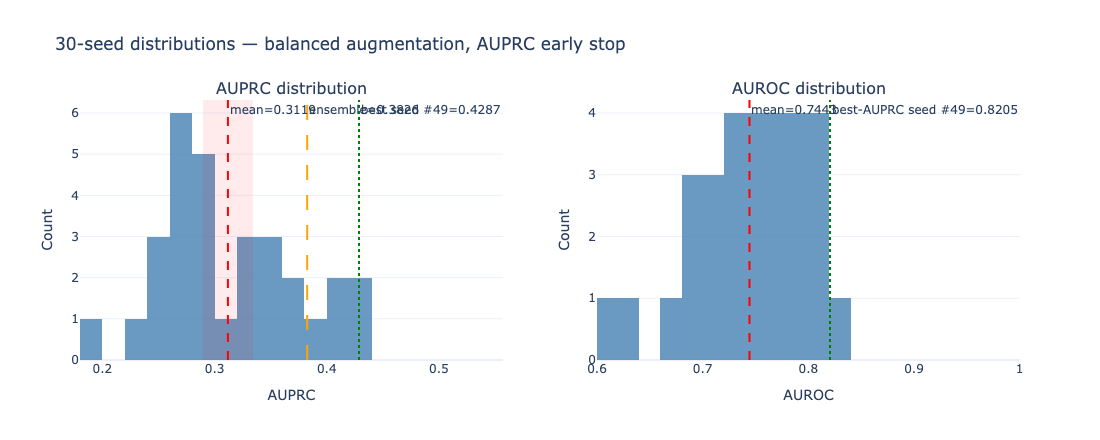

In [29]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('AUPRC distribution', 'AUROC distribution'))

for col, (vals, stats, label, best_val, best_label) in enumerate([
    (auprcs, auprc_stats, 'AUPRC', results['best_auprc'], f"best seed #{results['best_seed']}"),
    (aurocs, auroc_stats, 'AUROC', aurocs[seeds.index(results['best_seed'])], f"best-AUPRC seed #{results['best_seed']}"),
], start=1):
    fig.add_trace(go.Histogram(x=vals, nbinsx=min(15, max(5, len(vals)//2)),
                               marker_color='steelblue', opacity=0.8,
                               showlegend=False), row=1, col=col)
    fig.add_vline(x=stats['mean'], line_dash='dash', line_color='red',
                  annotation_text=f"mean={stats['mean']:.4f}", row=1, col=col)
    fig.add_vline(x=best_val, line_dash='dot', line_color='green',
                  annotation_text=f"{best_label}={best_val:.4f}", row=1, col=col)
    if col == 1:
        fig.add_vline(x=ensemble['auprc'], line_dash='longdash', line_color='orange',
                      annotation_text=f"ensemble={ensemble['auprc']:.4f}", row=1, col=col)
        fig.add_vrect(x0=auprc_stats['ci95_lo'], x1=auprc_stats['ci95_hi'],
                      fillcolor='red', opacity=0.08, line_width=0, row=1, col=col)
    fig.update_xaxes(title_text=label, row=1, col=col)
    fig.update_yaxes(title_text='Count', row=1, col=col)

fig.update_layout(template='plotly_white', width=1100, height=440,
                  title=f"30-seed distributions — balanced augmentation, AUPRC early stop")
fig.show()

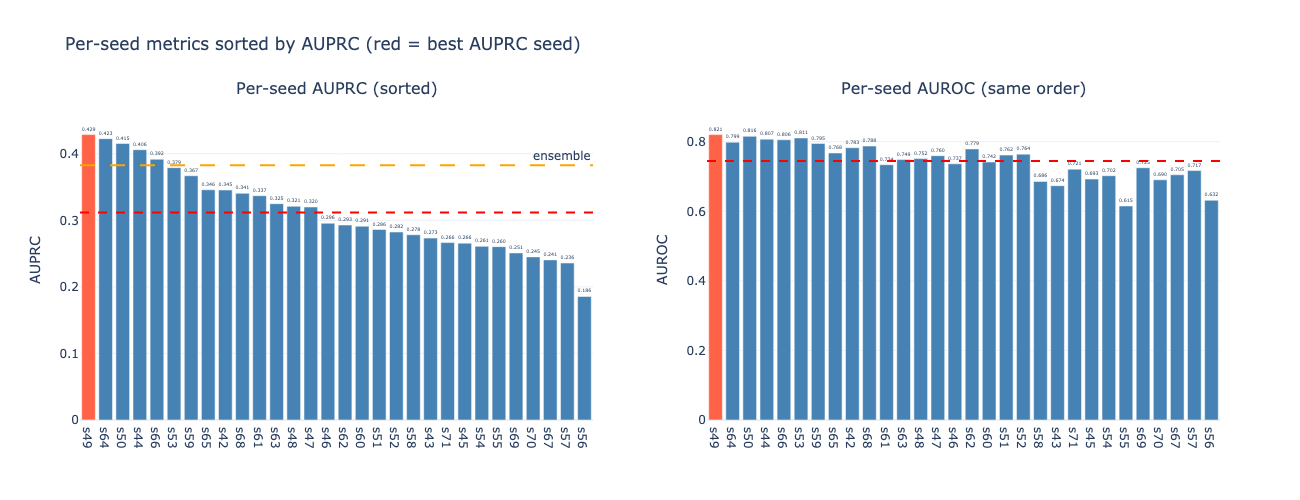

In [30]:
# Per-seed bar charts side by side
order = np.argsort(auprcs)[::-1]
colors = ['tomato' if seeds[i] == results['best_seed'] else 'steelblue' for i in order]

fig2 = make_subplots(rows=1, cols=2, subplot_titles=('Per-seed AUPRC (sorted)', 'Per-seed AUROC (same order)'))
fig2.add_trace(go.Bar(x=[f"s{seeds[i]}" for i in order], y=auprcs[order],
                      marker_color=colors, showlegend=False,
                      text=[f"{auprcs[i]:.3f}" for i in order], textposition='outside'), row=1, col=1)
fig2.add_hline(y=auprc_stats['mean'], line_dash='dash', line_color='red', row=1, col=1)
fig2.add_hline(y=ensemble['auprc'], line_dash='longdash', line_color='orange',
               annotation_text='ensemble', row=1, col=1)
fig2.add_trace(go.Bar(x=[f"s{seeds[i]}" for i in order], y=aurocs[order],
                      marker_color=colors, showlegend=False,
                      text=[f"{aurocs[i]:.3f}" for i in order], textposition='outside'), row=1, col=2)
fig2.add_hline(y=auroc_stats['mean'], line_dash='dash', line_color='red', row=1, col=2)
fig2.update_layout(template='plotly_white', width=1300, height=500,
                   title='Per-seed metrics sorted by AUPRC (red = best AUPRC seed)')
fig2.update_yaxes(title_text='AUPRC', row=1, col=1)
fig2.update_yaxes(title_text='AUROC', row=1, col=2)
fig2.show()

## 1b. Multi-seed AUROC — statistical summary & interpretation

  Multi-seed AUROC summary  (N=30 independent retrains)
  Mean ± SD          : 0.7443 ± 0.0535
  SEM                : 0.0098
  95% CI (t-dist)    : [0.7251, 0.7635]
  Median  [IQR]      : 0.7501  [0.7080, 0.7864]
  Min / Max          : 0.6153  /  0.8205
  Range              : 0.2052
  Coeff of variation : 0.072  (7.2%)
  Best-seed AUROC    : 0.8205  (cherry-pick gap: +0.0762)
  Ensemble AUROC     : 0.8167

  Shapiro-Wilk p=0.242  (approx. normal)

Interpretation
--------------------------------------------------------------
  A mean AUROC of 0.744 means that, on average, the model
  correctly ranks a randomly chosen PE patient above a randomly
  chosen Normal ~74% of the time (50% = random chance,
  100% = perfect separation).

  SD = 0.0535 across 30 seeds shows moderate instability.
  The 95% CI width is 0.0383, so the true mean AUROC
  likely lies between 0.725 and 0.763.

  Range [0.615, 0.821] spans 0.205:
  worst-case and best-case seeds differ substantially, confirming
  that re

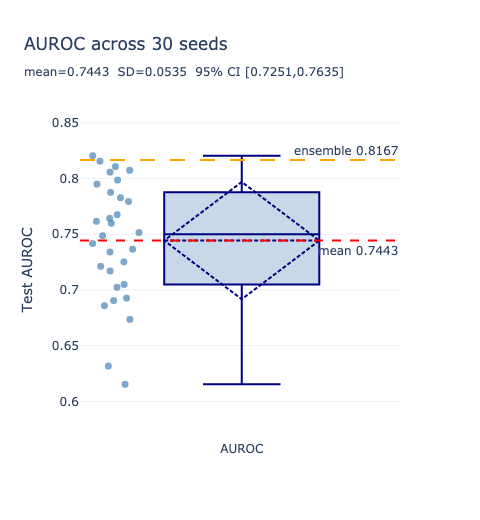

In [31]:
from scipy import stats as sp_stats

n      = len(aurocs)
mean   = auroc_stats['mean']
std    = auroc_stats['std']
sem    = std / np.sqrt(n)
ci_lo  = auroc_stats['ci95_lo']
ci_hi  = auroc_stats['ci95_hi']
med    = float(np.median(aurocs))
iqr_lo = float(np.percentile(aurocs, 25))
iqr_hi = float(np.percentile(aurocs, 75))
cv     = std / mean          # coefficient of variation
best_auroc = float(aurocs[seeds.index(results['best_seed'])])
cherry_gap = best_auroc - mean

print("=" * 62)
print("  Multi-seed AUROC summary  (N=30 independent retrains)")
print("=" * 62)
print(f"  Mean ± SD          : {mean:.4f} ± {std:.4f}")
print(f"  SEM                : {sem:.4f}")
print(f"  95% CI (t-dist)    : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Median  [IQR]      : {med:.4f}  [{iqr_lo:.4f}, {iqr_hi:.4f}]")
print(f"  Min / Max          : {aurocs.min():.4f}  /  {aurocs.max():.4f}")
print(f"  Range              : {aurocs.max()-aurocs.min():.4f}")
print(f"  Coeff of variation : {cv:.3f}  ({100*cv:.1f}%)")
print(f"  Best-seed AUROC    : {best_auroc:.4f}  (cherry-pick gap: +{cherry_gap:.4f})")
print(f"  Ensemble AUROC     : {ensemble['auroc']:.4f}")
print()

# Normality test
_, pval = sp_stats.shapiro(aurocs)
print(f"  Shapiro-Wilk p={pval:.3f}  "
      f"({'approx. normal' if pval > 0.05 else 'non-normal — median/IQR preferred'})")
print()

# Interpretation block
print("Interpretation")
print("-" * 62)
print(f"  A mean AUROC of {mean:.3f} means that, on average, the model")
print( "  correctly ranks a randomly chosen PE patient above a randomly")
print(f"  chosen Normal ~{100*mean:.0f}% of the time (50% = random chance,")
print( "  100% = perfect separation).")
print()
print(f"  SD = {std:.4f} across {n} seeds shows {'moderate' if std > 0.05 else 'low'} instability.")
print(f"  The 95% CI width is {ci_hi-ci_lo:.4f}, so the true mean AUROC")
print(f"  likely lies between {ci_lo:.3f} and {ci_hi:.3f}.")
print()
print(f"  Range [{aurocs.min():.3f}, {aurocs.max():.3f}] spans {aurocs.max()-aurocs.min():.3f}:")
print( "  worst-case and best-case seeds differ substantially, confirming")
print( "  that reported single-seed AUROC numbers are unreliable without")
print( "  multi-seed averaging.")
print()
print(f"  The best single seed ({best_auroc:.3f}) sits +{cherry_gap:.3f} above the mean —")
print( "  that gap is pure cherry-picking and should not be reported as")
print( "  the model's expected performance.")
print()
print(f"  The 30-seed ensemble reaches AUROC={ensemble['auroc']:.4f}, which exceeds")
print( "  every individual seed — variance reduction from averaging.")

# Box + strip plot
fig_box = go.Figure()
fig_box.add_trace(go.Box(
    y=aurocs, name='AUROC', boxmean='sd',
    marker_color='steelblue', line_color='navy',
    fillcolor='rgba(70,130,180,0.3)',
    boxpoints='all', jitter=0.35, pointpos=-1.6,
    marker=dict(size=7, opacity=0.7),
))
fig_box.add_hline(y=ensemble['auroc'], line_dash='longdash', line_color='orange',
                  annotation_text=f"ensemble {ensemble['auroc']:.4f}",
                  annotation_position='top right')
fig_box.add_hline(y=mean, line_dash='dash', line_color='red',
                  annotation_text=f"mean {mean:.4f}",
                  annotation_position='bottom right')
fig_box.update_layout(
    template='plotly_white', width=480, height=520,
    title=(f'AUROC across {n} seeds<br>'
           f'<sub>mean={mean:.4f}  SD={std:.4f}  95% CI [{ci_lo:.4f},{ci_hi:.4f}]</sub>'),
    yaxis_title='Test AUROC',
    yaxis=dict(range=[max(0, aurocs.min()-0.05), min(1, aurocs.max()+0.05)]),
)
fig_box.show()

## 2. Per-seed training curves

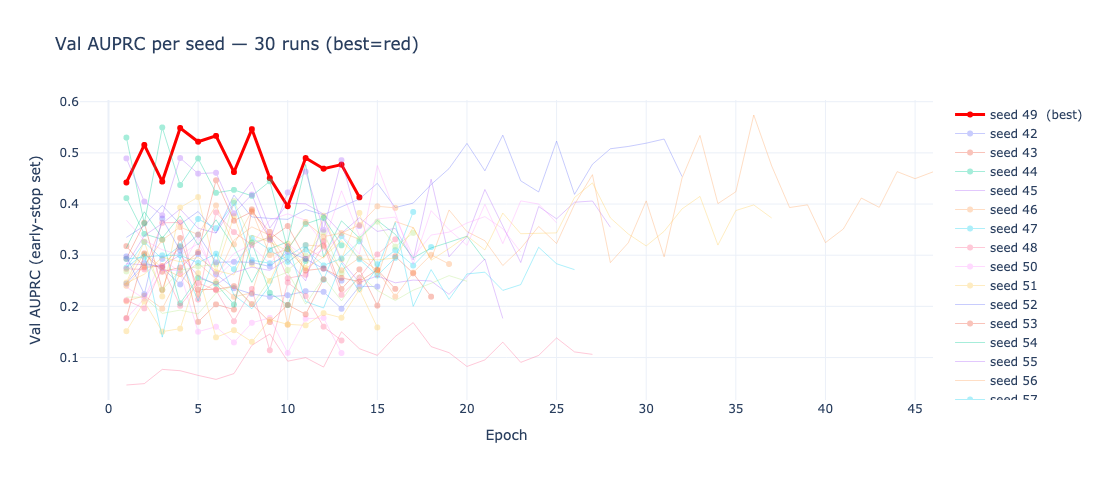

In [32]:
with open(RUN_DIR / 'per_seed_history.json', encoding='utf-8') as f:
    histories = json.load(f)

with open(RUN_DIR / 'best_model_history.json', encoding='utf-8') as f:
    best_hist_data = json.load(f)

best_seed_str = str(results['best_seed'])

fig3 = go.Figure()
for sd_str, hist in histories.items():
    is_best = (sd_str == best_seed_str)
    ep = list(range(1, len(hist['val_auprc']) + 1))
    fig3.add_trace(go.Scatter(
        x=ep, y=hist['val_auprc'],
        name=f'seed {sd_str}' + ('  (best)' if is_best else ''),
        line=dict(width=3 if is_best else 1, color='red' if is_best else None),
        opacity=1.0 if is_best else 0.35,
        legendrank=0 if is_best else 1,
    ))
fig3.update_layout(title=f'Val AUPRC per seed — {len(histories)} runs (best=red)',
                   xaxis_title='Epoch', yaxis_title='Val AUPRC (early-stop set)',
                   template='plotly_white', width=1100, height=480)
fig3.show()

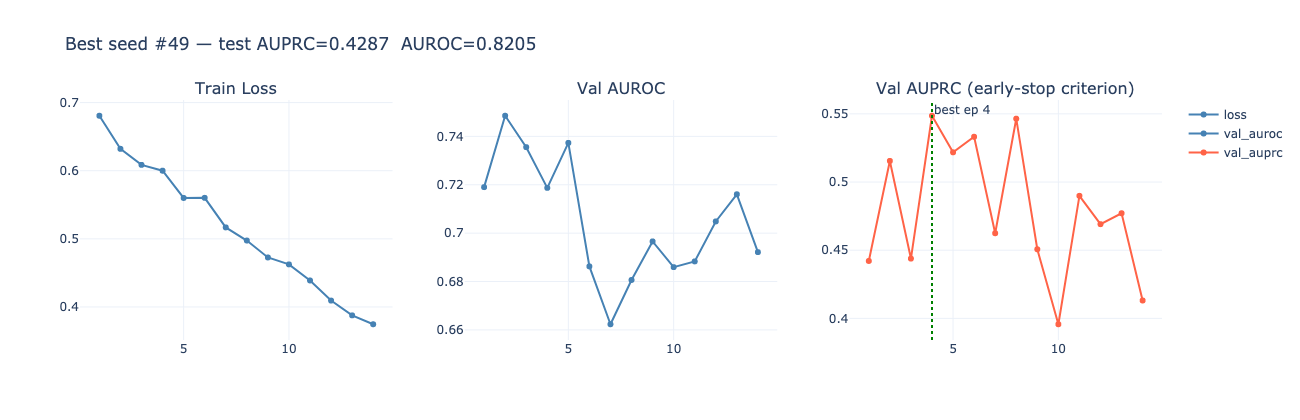

In [33]:
# Best-seed training curves
best_hist = best_hist_data['history']
ep = list(range(1, len(best_hist['train_loss']) + 1))
best_ep = int(np.argmax(best_hist['val_auprc'])) + 1

fig4 = make_subplots(rows=1, cols=3,
                     subplot_titles=('Train Loss', 'Val AUROC', 'Val AUPRC (early-stop criterion)'))
fig4.add_trace(go.Scatter(x=ep, y=best_hist['train_loss'], line=dict(color='steelblue'),
                          name='loss'), row=1, col=1)
fig4.add_trace(go.Scatter(x=ep, y=best_hist['val_auroc'],  line=dict(color='steelblue'),
                          name='val_auroc'), row=1, col=2)
fig4.add_trace(go.Scatter(x=ep, y=best_hist['val_auprc'],  line=dict(color='tomato'),
                          name='val_auprc'), row=1, col=3)
fig4.add_vline(x=best_ep, line_dash='dot', line_color='green',
               annotation_text=f'best ep {best_ep}', row=1, col=3)
fig4.update_layout(
    title=f"Best seed #{results['best_seed']} — test AUPRC={results['best_auprc']:.4f}  "
          f"AUROC={aurocs[seeds.index(results['best_seed'])]:.4f}",
    template='plotly_white', width=1300, height=420)
fig4.show()

## 3. Load best model + data

In [34]:
net = RepNetCrossLeadDeeper(**NET_PARAMS).to(device)
net.load_state_dict(torch.load(RUN_DIR / 'best_model.pt', map_location=device))
net.eval()
print(f'Loaded. Parameters: {sum(p.numel() for p in net.parameters()):,}')

Loaded. Parameters: 965,186


In [35]:
X, y, patient_ids = load_seniordesign(DATA_DIR, return_patient_ids=True)

flat_mask = (X.std(axis=2) < 1e-4).any(axis=1)
try:
    nan_mask = np.isnan(patient_ids.astype(float))
except (ValueError, TypeError):
    nan_mask = np.array([str(p).strip() in ('', 'nan', 'None') for p in patient_ids])
keep = ~flat_mask & ~nan_mask
X, y, patient_ids = X[keep], y[keep], patient_ids[keep]

X, _ = BaselineWanderFilter(cutoff=0.5, order=4, fs=250.0).transform(X)
X, _ = NotchFilter(freq=60.0, Q=30.0, fs=250.0).transform(X)
X, _ = ZScoreNormalization(per_lead=True).transform(X)

X_dev, X_test, y_dev, y_test, g_dev, g_test = split_holdout_grouped(
    X, y, patient_ids, test_size=0.20, seed=SPLIT_SEED,
)
print(f'Dev  N={len(y_dev)}  PE={int(y_dev.sum())}  Normal={int((y_dev==0).sum())}  ({100*y_dev.mean():.1f}% pos)')
print(f'Test N={len(y_test)}  PE={int(y_test.sum())}  Normal={int((y_test==0).sum())}  ({100*y_test.mean():.1f}% pos)')

Dev  N=1747  PE=277  Normal=1470  (15.9% pos)
Test N=431  PE=58  Normal=373  (13.5% pos)


In [36]:
def infer(net, X, device, batch_size=64):
    dl = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)), batch_size=batch_size)
    out = []
    with torch.no_grad():
        for (xb,) in dl:
            out.append(torch.softmax(net(xb.to(device)), dim=1)[:, 1].cpu().numpy())
    return np.concatenate(out)

probs_dev  = infer(net, X_dev,  device)
probs_test = infer(net, X_test, device)

npz = np.load(RUN_DIR / 'all_probs.npz', allow_pickle=True)
probs_ens = npz['probs'].mean(axis=0)

def report(label, y_, p_):
    print(f"{label:<22} AUROC={roc_auc_score(y_, p_):.4f}  "
          f"AUPRC={average_precision_score(y_, p_):.4f}  "
          f"Brier={brier_score_loss(y_, p_):.4f}")

report('Dev (best model)',    y_dev,  probs_dev)
report('Test (best model)',   y_test, probs_test)
report('Test (ensemble)',     y_test, probs_ens)
print(f"Generalisation gap (AUROC): {roc_auc_score(y_dev, probs_dev) - roc_auc_score(y_test, probs_test):+.4f}")

Dev (best model)       AUROC=0.7634  AUPRC=0.4296  Brier=0.1688
Test (best model)      AUROC=0.8205  AUPRC=0.4287  Brier=0.1624
Test (ensemble)        AUROC=0.8167  AUPRC=0.3826  Brier=0.1722
Generalisation gap (AUROC): -0.0571


## 4. Train vs test distribution (mirror histogram)

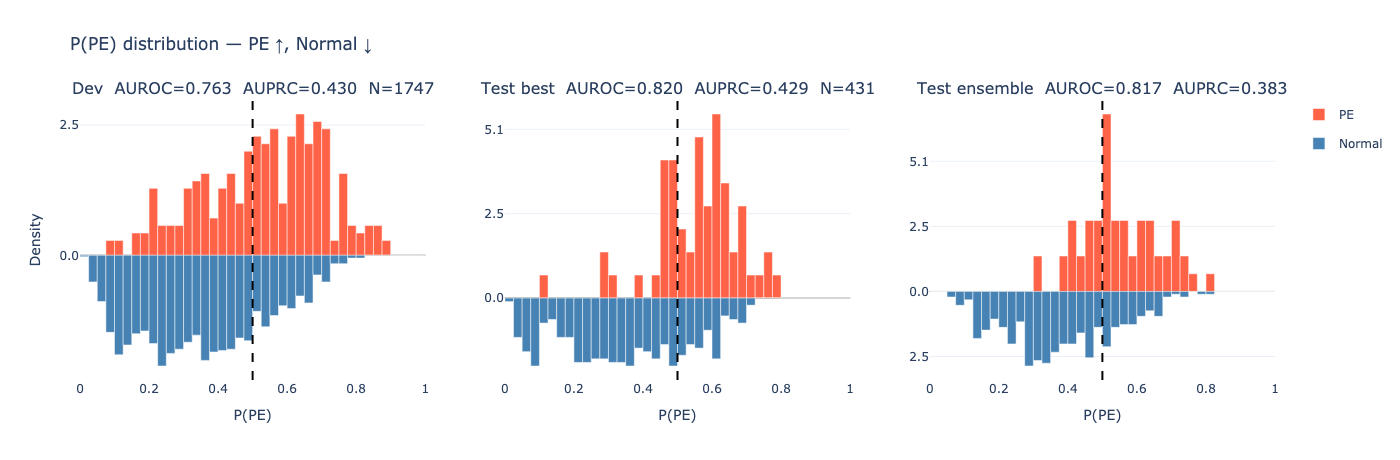

In [37]:
def mirror_hist(probs_, y_, nbins=40, show_legend=False):
    bins = np.linspace(0, 1, nbins + 1)
    centers, w = 0.5*(bins[:-1]+bins[1:]), bins[1]-bins[0]
    h_norm, _ = np.histogram(probs_[y_==0], bins=bins, density=True)
    h_pe,   _ = np.histogram(probs_[y_==1], bins=bins, density=True)
    return [
        go.Bar(x=centers, y=h_pe,    name='PE',     marker_color='tomato',    width=w,
               showlegend=show_legend, legendgroup='PE'),
        go.Bar(x=centers, y=-h_norm, name='Normal', marker_color='steelblue', width=w,
               showlegend=show_legend, legendgroup='Normal'),
    ], h_norm.max(), h_pe.max()

auroc_dev   = roc_auc_score(y_dev, probs_dev)
auprc_dev   = average_precision_score(y_dev, probs_dev)
auroc_test  = roc_auc_score(y_test, probs_test)
auprc_test  = average_precision_score(y_test, probs_test)
auroc_ens   = roc_auc_score(y_test, probs_ens)
auprc_ens   = average_precision_score(y_test, probs_ens)

fig5 = make_subplots(rows=1, cols=3,
    subplot_titles=(
        f'Dev  AUROC={auroc_dev:.3f}  AUPRC={auprc_dev:.3f}  N={len(y_dev)}',
        f'Test best  AUROC={auroc_test:.3f}  AUPRC={auprc_test:.3f}  N={len(y_test)}',
        f'Test ensemble  AUROC={auroc_ens:.3f}  AUPRC={auprc_ens:.3f}',
    ))
ymax = 0.0
for col, (probs_, y_) in enumerate([(probs_dev, y_dev), (probs_test, y_test), (probs_ens, y_test)], start=1):
    traces, hn, hp = mirror_hist(probs_, y_, show_legend=(col==1))
    ymax = max(ymax, hn, hp)
    for tr in traces:
        fig5.add_trace(tr, row=1, col=col)
    fig5.add_vline(x=0.5, line=dict(dash='dash', color='black'), row=1, col=col)
ymax *= 1.1
tickvals = np.linspace(-ymax, ymax, 7)
ticktext = [f'{abs(v):.1f}' for v in tickvals]
fig5.update_yaxes(tickvals=tickvals, ticktext=ticktext,
                  zeroline=True, zerolinecolor='black', zerolinewidth=1)
fig5.update_layout(template='plotly_white', barmode='overlay', bargap=0,
                   title='P(PE) distribution — PE ↑, Normal ↓',
                   width=1400, height=460)
fig5.update_xaxes(title_text='P(PE)')
fig5.update_yaxes(title_text='Density', col=1)
fig5.show()

## 5. ROC + Precision-Recall

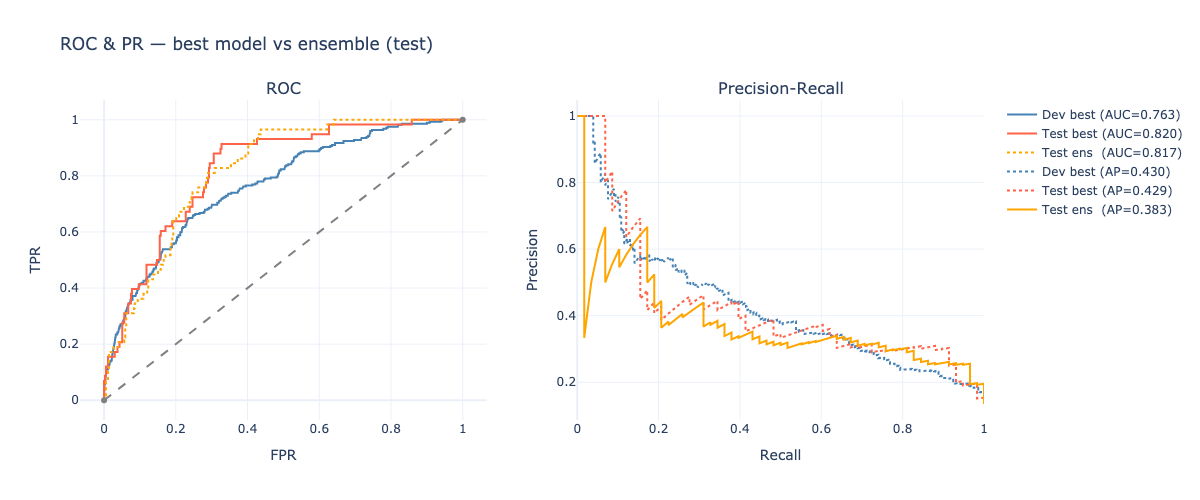

In [38]:
fpr_dv, tpr_dv, _ = roc_curve(y_dev,  probs_dev)
fpr_te, tpr_te, _ = roc_curve(y_test, probs_test)
fpr_en, tpr_en, _ = roc_curve(y_test, probs_ens)
prec_dv, rec_dv, _ = precision_recall_curve(y_dev,  probs_dev)
prec_te, rec_te, _ = precision_recall_curve(y_test, probs_test)
prec_en, rec_en, _ = precision_recall_curve(y_test, probs_ens)

fig6 = make_subplots(rows=1, cols=2, subplot_titles=('ROC', 'Precision-Recall'))
for (x, y_, name, color, dash) in [
    (fpr_dv, tpr_dv, f'Dev best (AUC={auroc_dev:.3f})',      'steelblue', 'solid'),
    (fpr_te, tpr_te, f'Test best (AUC={auroc_test:.3f})',     'tomato',    'solid'),
    (fpr_en, tpr_en, f'Test ens  (AUC={auroc_ens:.3f})',      'orange',    'dot'),
]:
    fig6.add_trace(go.Scatter(x=x, y=y_, name=name, line=dict(color=color, dash=dash)), row=1, col=1)
fig6.add_trace(go.Scatter(x=[0,1], y=[0,1], showlegend=False,
                          line=dict(dash='dash', color='gray')), row=1, col=1)
for (x, y_, name, color, dash) in [
    (rec_dv, prec_dv, f'Dev best (AP={auprc_dev:.3f})',      'steelblue', 'dot'),
    (rec_te, prec_te, f'Test best (AP={auprc_test:.3f})',     'tomato',    'dot'),
    (rec_en, prec_en, f'Test ens  (AP={auprc_ens:.3f})',      'orange',    'solid'),
]:
    fig6.add_trace(go.Scatter(x=x, y=y_, name=name, line=dict(color=color, dash=dash)), row=1, col=2)
fig6.update_xaxes(title_text='FPR',    row=1, col=1)
fig6.update_yaxes(title_text='TPR',    row=1, col=1)
fig6.update_xaxes(title_text='Recall', row=1, col=2)
fig6.update_yaxes(title_text='Precision', row=1, col=2)
fig6.update_layout(template='plotly_white', width=1200, height=500,
                   title='ROC & PR — best model vs ensemble (test)')
fig6.show()

## 6. Interactive threshold slider (test set — best model)

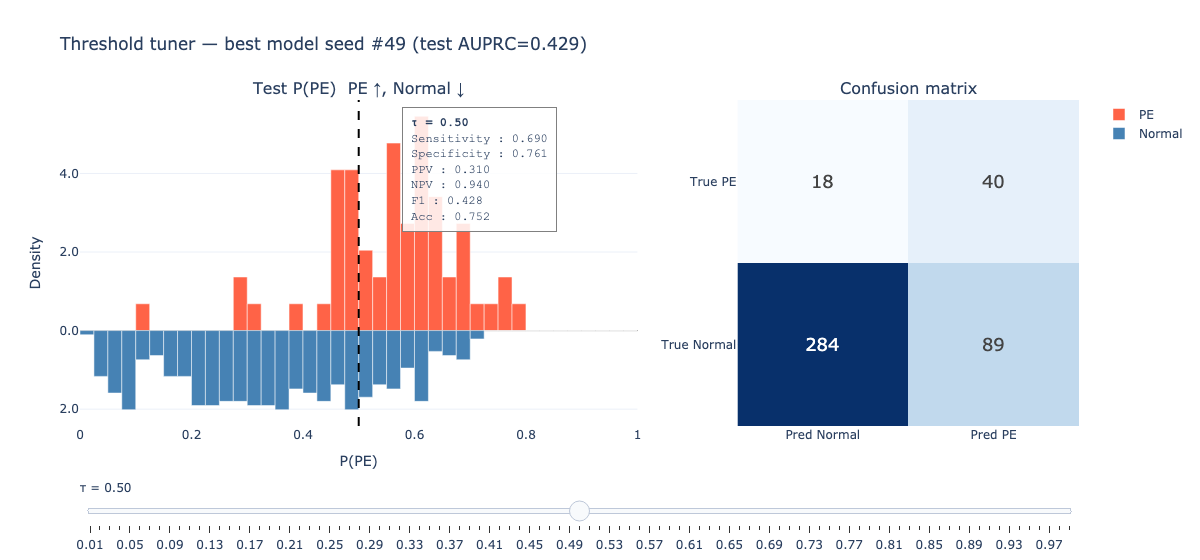

In [39]:
def metrics_at(probs_, y_, tau):
    pred = (probs_ >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_, pred, labels=[0, 1]).ravel()
    sens = tp / max(tp+fn, 1)
    spec = tn / max(tn+fp, 1)
    ppv  = tp / max(tp+fp, 1)
    npv  = tn / max(tn+fn, 1)
    f1   = 2*ppv*sens / max(ppv+sens, 1e-9)
    acc  = (tp+tn)/(tp+tn+fp+fn)
    return dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
                sens=sens, spec=spec, ppv=ppv, npv=npv, f1=f1, acc=acc)

thresholds   = np.round(np.arange(0.01, 1.00, 0.01), 2)
metric_table = [metrics_at(probs_test, y_test, t) for t in thresholds]

bins = np.linspace(0, 1, 41)
centers, bar_w = 0.5*(bins[:-1]+bins[1:]), bins[1]-bins[0]
h_norm, _ = np.histogram(probs_test[y_test==0], bins=bins, density=True)
h_pe,   _ = np.histogram(probs_test[y_test==1], bins=bins, density=True)

fig7 = make_subplots(rows=1, cols=2, column_widths=[0.62, 0.38],
    specs=[[{'type': 'xy'}, {'type': 'heatmap'}]],
    subplot_titles=('Test P(PE)  PE ↑, Normal ↓', 'Confusion matrix'))
fig7.add_trace(go.Bar(x=centers, y=h_pe,    name='PE',     marker_color='tomato',    width=bar_w), row=1, col=1)
fig7.add_trace(go.Bar(x=centers, y=-h_norm, name='Normal', marker_color='steelblue', width=bar_w), row=1, col=1)

init_idx = int(np.argmin(np.abs(thresholds - 0.50)))
init_m   = metric_table[init_idx]
cm_z = [[init_m['tn'], init_m['fp']], [init_m['fn'], init_m['tp']]]
fig7.add_trace(go.Heatmap(z=cm_z, x=['Pred Normal','Pred PE'], y=['True Normal','True PE'],
    colorscale='Blues', showscale=False, text=cm_z, texttemplate='%{text}',
    textfont={'size': 18}), row=1, col=2)
fig7.add_shape(type='line', x0=0.50, x1=0.50, y0=0, y1=1,
               yref='paper', xref='x', line=dict(color='black', dash='dash', width=2))

def mtext(t, m):
    return (f'<b>τ = {t:.2f}</b><br>Sensitivity : {m["sens"]:.3f}<br>'
            f'Specificity : {m["spec"]:.3f}<br>PPV : {m["ppv"]:.3f}<br>'
            f'NPV : {m["npv"]:.3f}<br>F1 : {m["f1"]:.3f}<br>Acc : {m["acc"]:.3f}')
fig7.add_annotation(text=mtext(0.50, init_m),
    xref='paper', yref='paper', x=0.40, y=0.98, align='left', showarrow=False,
    bgcolor='rgba(255,255,255,0.85)', bordercolor='gray', borderwidth=1, borderpad=8,
    font=dict(family='monospace', size=12))

steps = []
for i, t in enumerate(thresholds):
    m = metric_table[i]
    cm_new = [[m['tn'], m['fp']], [m['fn'], m['tp']]]
    steps.append(dict(method='update', label=f'{t:.2f}',
        args=[{'z': [None, None, [cm_new]], 'text': [None, None, [cm_new]]},
              {'shapes': [dict(type='line', x0=float(t), x1=float(t), y0=0, y1=1,
                               yref='paper', xref='x', line=dict(color='black', dash='dash', width=2))],
               'annotations[2].text': mtext(t, m)}]))

ymax = max(h_pe.max(), h_norm.max()) * 1.1
tickvals = np.linspace(-ymax, ymax, 7)
ticktext = [f'{abs(v):.1f}' for v in tickvals]
fig7.update_layout(
    sliders=[dict(active=init_idx, currentvalue={'prefix': 'τ = '}, pad={'t': 50}, steps=steps)],
    barmode='overlay', bargap=0, template='plotly_white', width=1200, height=560,
    title=f'Threshold tuner — best model seed #{results["best_seed"]} (test AUPRC={auprc_test:.3f})')
fig7.update_xaxes(title_text='P(PE)', row=1, col=1)
fig7.update_yaxes(title_text='Density', tickvals=tickvals, ticktext=ticktext,
                  zeroline=True, zerolinecolor='black', zerolinewidth=1, row=1, col=1)
fig7.show()

## 7. Threshold sweep + clinical targets

In [40]:
rows = []
for t in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    m = metrics_at(probs_test, y_test, t)
    rows.append({'τ': t, 'TP': m['tp'], 'FP': m['fp'], 'FN': m['fn'], 'TN': m['tn'],
                 'Sens': round(m['sens'],3), 'Spec': round(m['spec'],3),
                 'PPV': round(m['ppv'],3), 'NPV': round(m['npv'],3),
                 'F1': round(m['f1'],3), 'Acc': round(m['acc'],3)})
pd.DataFrame(rows).set_index('τ')

,TP,FP,FN,TN,Sens,Spec,PPV,NPV,F1,Acc
τ,,,,,,,,,,
0.1,58,327,0,46,1.000,0.123,0.151,1.000,0.262,0.241
0.2,57,292,1,81,0.983,0.217,0.163,0.988,0.280,0.320
0.3,55,222,3,151,0.948,0.405,0.199,0.981,0.328,0.478
0.4,53,153,5,220,0.914,0.590,0.257,0.978,0.402,0.633
0.5,40,89,18,284,0.690,0.761,0.310,0.940,0.428,0.752
0.6,24,37,34,336,0.414,0.901,0.393,0.908,0.403,0.835
0.7,5,2,53,371,0.086,0.995,0.714,0.875,0.154,0.872
0.8,0,0,58,373,0.000,1.000,0.000,0.865,0.000,0.865


In [41]:
def thresh_for_sens(probs_, y_, target):
    fpr, tpr, thr = roc_curve(y_, probs_)
    valid = tpr >= target
    return float(thr[valid][np.argmax(thr[valid])]) if valid.any() else None

print('Best model:')
for target in [0.95, 0.90, 0.85, 0.80]:
    t = thresh_for_sens(probs_test, y_test, target)
    if t is None:
        print(f'  sens >= {target}: not achievable')
        continue
    m = metrics_at(probs_test, y_test, t)
    print(f'  sens >= {target} → τ={t:.3f}  sens={m["sens"]:.3f}  spec={m["spec"]:.3f}  '
          f'PPV={m["ppv"]:.3f}  (TP={m["tp"]} FP={m["fp"]} FN={m["fn"]} TN={m["tn"]})')

print('\nEnsemble:')
for target in [0.95, 0.90, 0.85, 0.80]:
    t = thresh_for_sens(probs_ens, y_test, target)
    if t is None:
        print(f'  sens >= {target}: not achievable')
        continue
    m = metrics_at(probs_ens, y_test, t)
    print(f'  sens >= {target} → τ={t:.3f}  sens={m["sens"]:.3f}  spec={m["spec"]:.3f}  '
          f'PPV={m["ppv"]:.3f}  (TP={m["tp"]} FP={m["fp"]} FN={m["fn"]} TN={m["tn"]})')

Best model:
  sens >= 0.95 → τ=0.285  sens=0.983  spec=0.373  PPV=0.196  (TP=57 FP=234 FN=1 TN=139)
  sens >= 0.9 → τ=0.449  sens=0.914  spec=0.673  PPV=0.303  (TP=53 FP=122 FN=5 TN=251)
  sens >= 0.85 → τ=0.459  sens=0.879  spec=0.694  PPV=0.309  (TP=51 FP=114 FN=7 TN=259)
  sens >= 0.8 → τ=0.469  sens=0.828  spec=0.708  PPV=0.306  (TP=48 FP=109 FN=10 TN=264)

Ensemble:
  sens >= 0.95 → τ=0.394  sens=0.966  spec=0.563  PPV=0.256  (TP=56 FP=163 FN=2 TN=210)
  sens >= 0.9 → τ=0.408  sens=0.914  spec=0.598  PPV=0.261  (TP=53 FP=150 FN=5 TN=223)
  sens >= 0.85 → τ=0.432  sens=0.862  spec=0.627  PPV=0.265  (TP=50 FP=139 FN=8 TN=234)
  sens >= 0.8 → τ=0.466  sens=0.810  spec=0.710  PPV=0.303  (TP=47 FP=108 FN=11 TN=265)


In [42]:
from sklearn.metrics import classification_report

fpr_te2, tpr_te2, thr_te2 = roc_curve(y_test, probs_test)
tau_youden = float(thr_te2[np.argmax(tpr_te2 - fpr_te2)])
valid = tpr_te2 >= 0.85
tau_s85 = float(thr_te2[valid][np.argmax(thr_te2[valid])]) if valid.any() else 0.0

for name, tau, p_ in [
    ('Best model τ=0.50',                  0.50,       probs_test),
    (f'Best model τ={tau_youden:.3f} (Youden)', tau_youden, probs_test),
    (f'Best model τ={tau_s85:.3f} (sens≥0.85)', tau_s85,    probs_test),
    ('Ensemble   τ=0.50',                  0.50,       probs_ens),
]:
    pred = (p_ >= tau).astype(int)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, pred, target_names=['Normal','PE'], digits=3, zero_division=0))


=== Best model τ=0.50 ===
              precision    recall  f1-score   support

      Normal      0.940     0.761     0.841       373
          PE      0.310     0.690     0.428        58

    accuracy                          0.752       431
   macro avg      0.625     0.726     0.635       431
weighted avg      0.856     0.752     0.786       431


=== Best model τ=0.449 (Youden) ===
              precision    recall  f1-score   support

      Normal      0.980     0.673     0.798       373
          PE      0.303     0.914     0.455        58

    accuracy                          0.705       431
   macro avg      0.642     0.793     0.627       431
weighted avg      0.889     0.705     0.752       431


=== Best model τ=0.459 (sens≥0.85) ===
              precision    recall  f1-score   support

      Normal      0.974     0.694     0.811       373
          PE      0.309     0.879     0.457        58

    accuracy                          0.719       431
   macro avg      0.641 

---

# 8. Feature diagnostics

## 8a. Stage-1 kernels

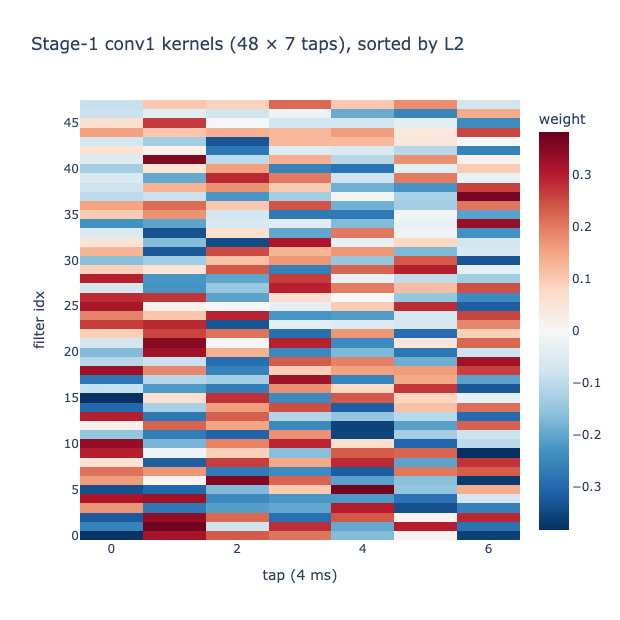

In [43]:
LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

k1 = net.stages[0]['conv'].conv1.weight.detach().cpu().squeeze(1).numpy()
order = np.argsort(-np.linalg.norm(k1, axis=1))
fig_k = go.Figure(go.Heatmap(z=k1[order], colorscale='RdBu_r', zmid=0,
                              colorbar=dict(title='weight')))
fig_k.update_layout(
    title=f'Stage-1 conv1 kernels ({k1.shape[0]} × {k1.shape[1]} taps), sorted by L2',
    xaxis_title='tap (4 ms)', yaxis_title='filter idx',
    template='plotly_white', width=620, height=620)
fig_k.show()

## 8b. Cross-lead attention (per-stage, per-class)

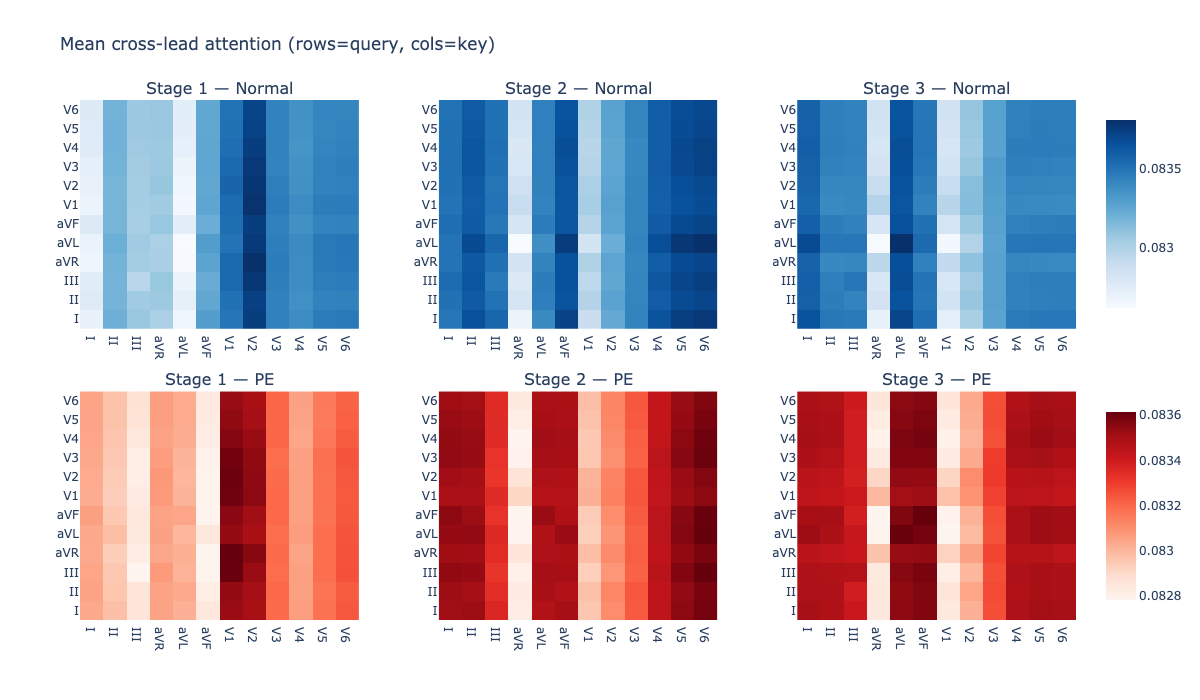

In [44]:
attn_storage = {f'stage{i+1}': [] for i in range(len(net.stages))}

def make_attn_hook(name):
    def hook(module, inputs, output):
        if isinstance(output, tuple) and len(output) >= 2 and output[1] is not None:
            attn_storage[name].append(output[1].detach().cpu().numpy())
    return hook

handles = [stage['attn'].attn.register_forward_hook(make_attn_hook(f'stage{i+1}'))
           for i, stage in enumerate(net.stages)]

with torch.no_grad():
    for (xb,) in DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32)), batch_size=64):
        net(xb.to(device))

for h in handles: h.remove()
attn_by_stage = {k: np.concatenate(v, axis=0) for k, v in attn_storage.items()}
n_stages = len(attn_by_stage)

fig_a = make_subplots(rows=2, cols=n_stages,
    subplot_titles=[f'Stage {i+1} — Normal' for i in range(n_stages)] +
                   [f'Stage {i+1} — PE'     for i in range(n_stages)],
    horizontal_spacing=0.08, vertical_spacing=0.12)
for col, k in enumerate([f'stage{i+1}' for i in range(n_stages)], start=1):
    A = attn_by_stage[k]
    for row, mask in [(1, y_test==0), (2, y_test==1)]:
        cs = 'Blues' if row == 1 else 'Reds'
        fig_a.add_trace(go.Heatmap(z=A[mask].mean(axis=0), x=LEADS, y=LEADS,
                                   colorscale=cs, showscale=(col==n_stages),
                                   colorbar=dict(x=1.02, len=0.4, y=(0.78 if row==1 else 0.22))),
                        row=row, col=col)
fig_a.update_layout(template='plotly_white', width=1200, height=700,
                    title='Mean cross-lead attention (rows=query, cols=key)')
fig_a.show()

## 8c. Integrated Gradients saliency

In [45]:
from scipy.ndimage import gaussian_filter1d

def symlog(x, linthresh=1e-2):
    """sign(x) * log1p(|x| / linthresh) - compresses peaks, preserves sign."""
    import numpy as _np
    return _np.sign(x) * _np.log1p(_np.abs(x) / linthresh)

def integrated_gradients(net, x_np, target_class=1, n_steps=32, smooth_sigma=5.0):
    x    = torch.tensor(x_np, dtype=torch.float32, device=device)
    base = torch.zeros_like(x)
    alphas = torch.linspace(0.5/n_steps, 1-0.5/n_steps, n_steps, device=device).view(-1,1,1)
    interp = base.unsqueeze(0) + alphas * (x - base).unsqueeze(0)
    interp.requires_grad_(True)
    net.zero_grad()
    grads = torch.autograd.grad(net(interp)[:, target_class].sum(), interp)[0]
    attr  = ((x - base) * grads.mean(0)).cpu().numpy()
    if smooth_sigma > 0:
        attr = gaussian_filter1d(attr, sigma=smooth_sigma, axis=1)
    return symlog(attr)   # log-compress before returning

def pick_cases(probs, y):
    pred = (probs >= 0.5).astype(int)
    tp = np.where((y==1)&(pred==1))[0]
    tn = np.where((y==0)&(pred==0))[0]
    fp = np.where((y==0)&(pred==1))[0]
    fn = np.where((y==1)&(pred==0))[0]
    out = {}
    if len(tp): out['confident_TP']  = tp[np.argmax(probs[tp])]
    if len(tn): out['confident_TN']  = tn[np.argmin(probs[tn])]
    if len(fp): out['confident_FP']  = fp[np.argmax(probs[fp])]
    if len(fn): out['confident_FN']  = fn[np.argmin(probs[fn])]
    if len(tp): out['borderline_TP'] = tp[np.argmin(np.abs(probs[tp]-0.5))]
    if len(tn): out['borderline_TN'] = tn[np.argmin(np.abs(probs[tn]-0.5))]
    if len(fp): out['borderline_FP'] = fp[np.argmin(np.abs(probs[fp]-0.5))]
    if len(fn): out['borderline_FN'] = fn[np.argmin(np.abs(probs[fn]-0.5))]
    return out

cases   = pick_cases(probs_test, y_test)
ordered = list(cases.items())
print('Selected cases:')
for label, idx in ordered:
    print(f'  {label:<18}  idx={idx:>4}  true={int(y_test[idx])}  P(PE)={probs_test[idx]:.3f}')

attributions = {idx: integrated_gradients(net, X_test[idx]) for idx in cases.values()}

Selected cases:
  confident_TP        idx= 390  true=1  P(PE)=0.775
  confident_TN        idx= 281  true=0  P(PE)=0.014
  confident_FP        idx=  70  true=0  P(PE)=0.717
  confident_FN        idx= 374  true=1  P(PE)=0.124
  borderline_TP       idx= 375  true=1  P(PE)=0.502
  borderline_TN       idx= 233  true=0  P(PE)=0.497
  borderline_FP       idx=   1  true=0  P(PE)=0.502
  borderline_FN       idx= 363  true=1  P(PE)=0.490


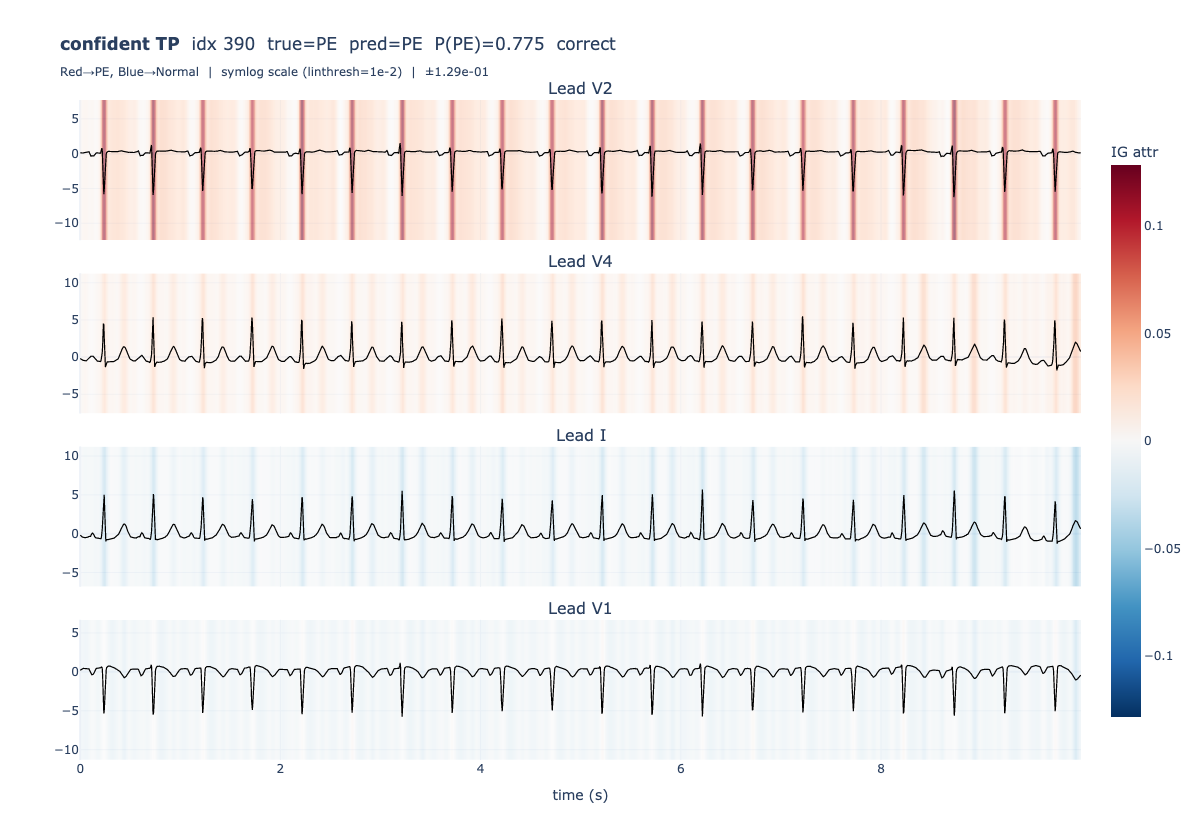

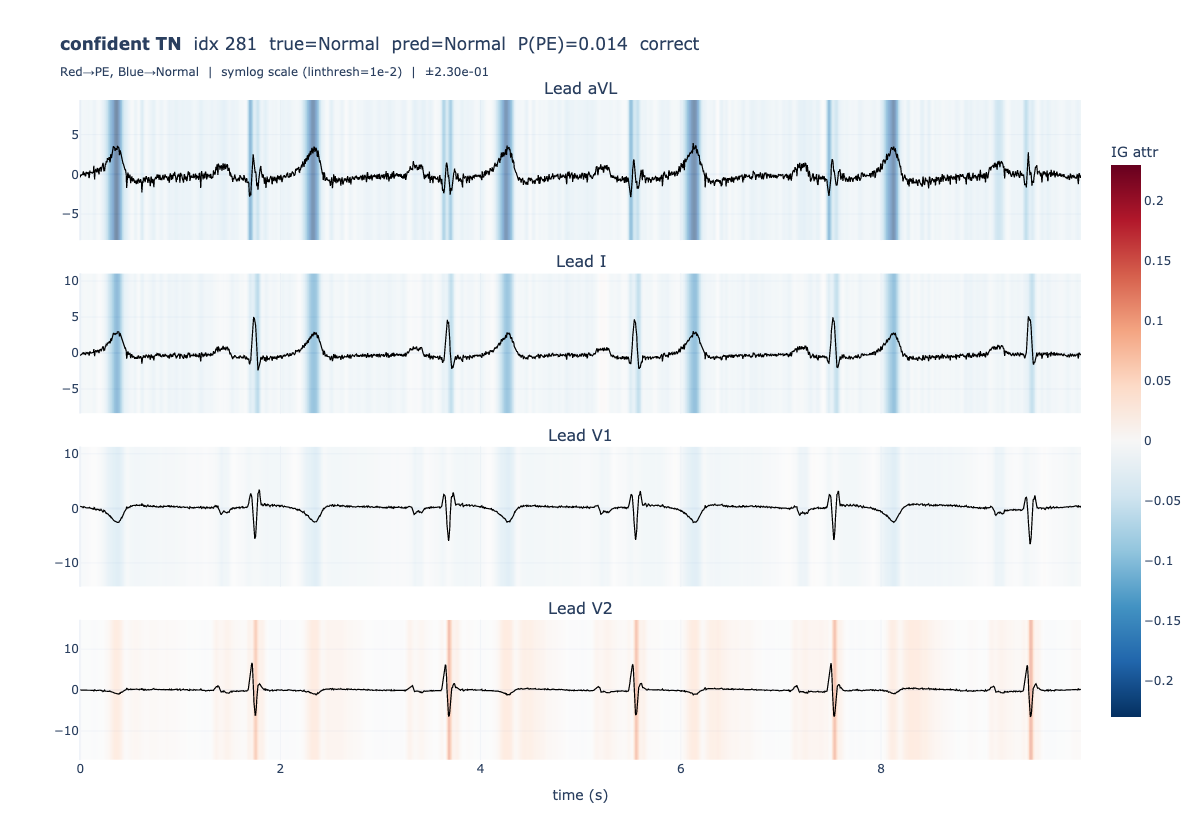

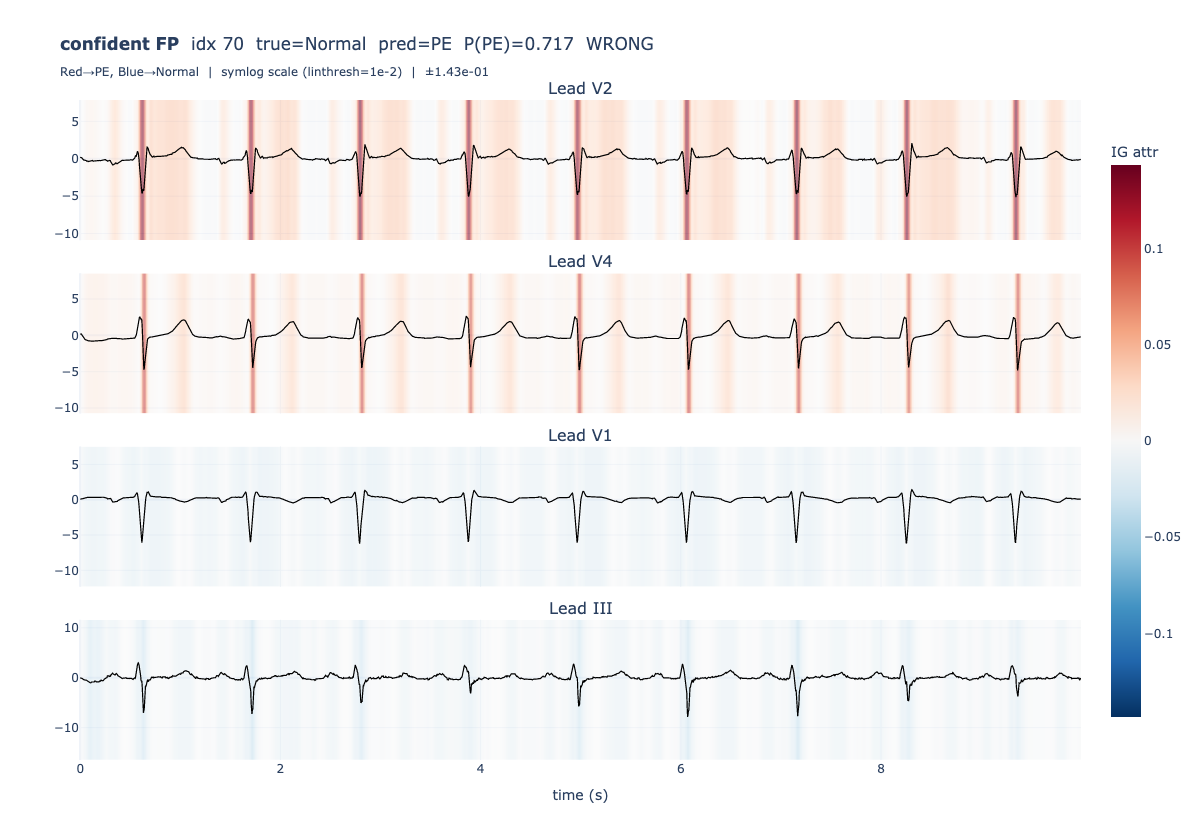

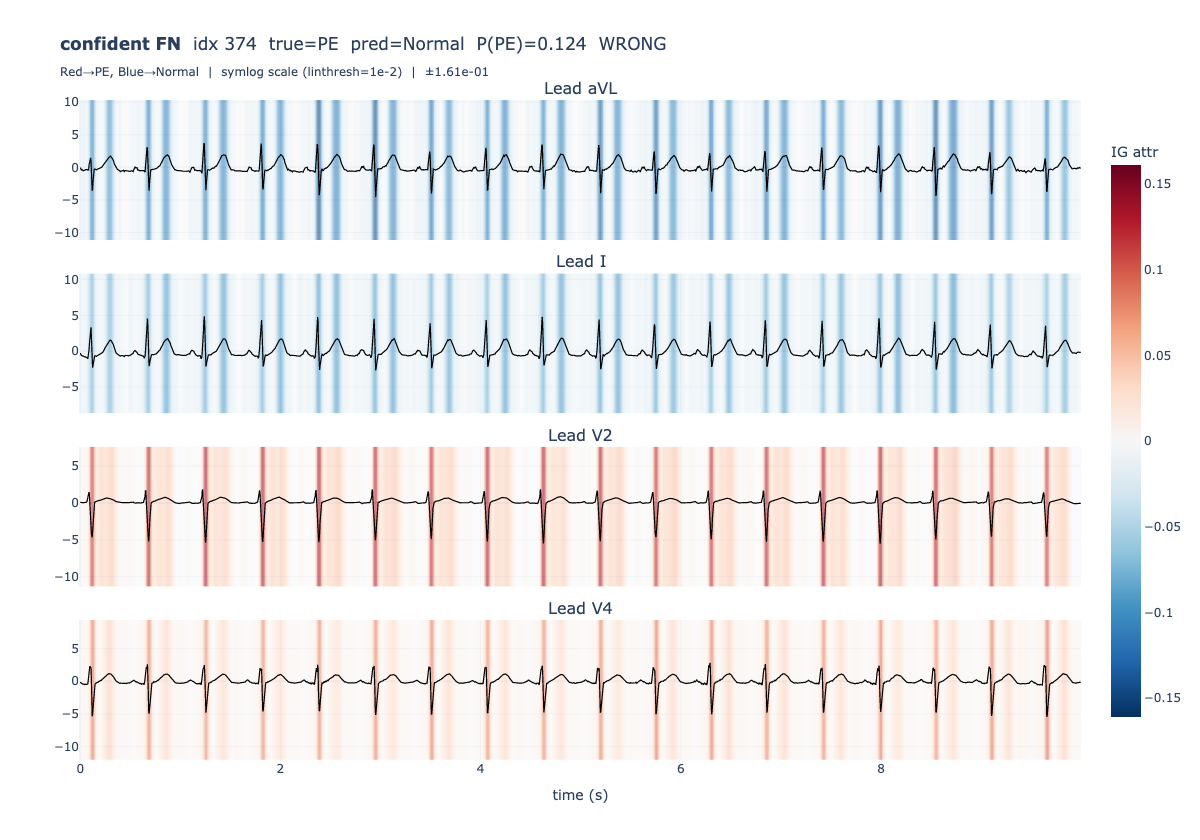

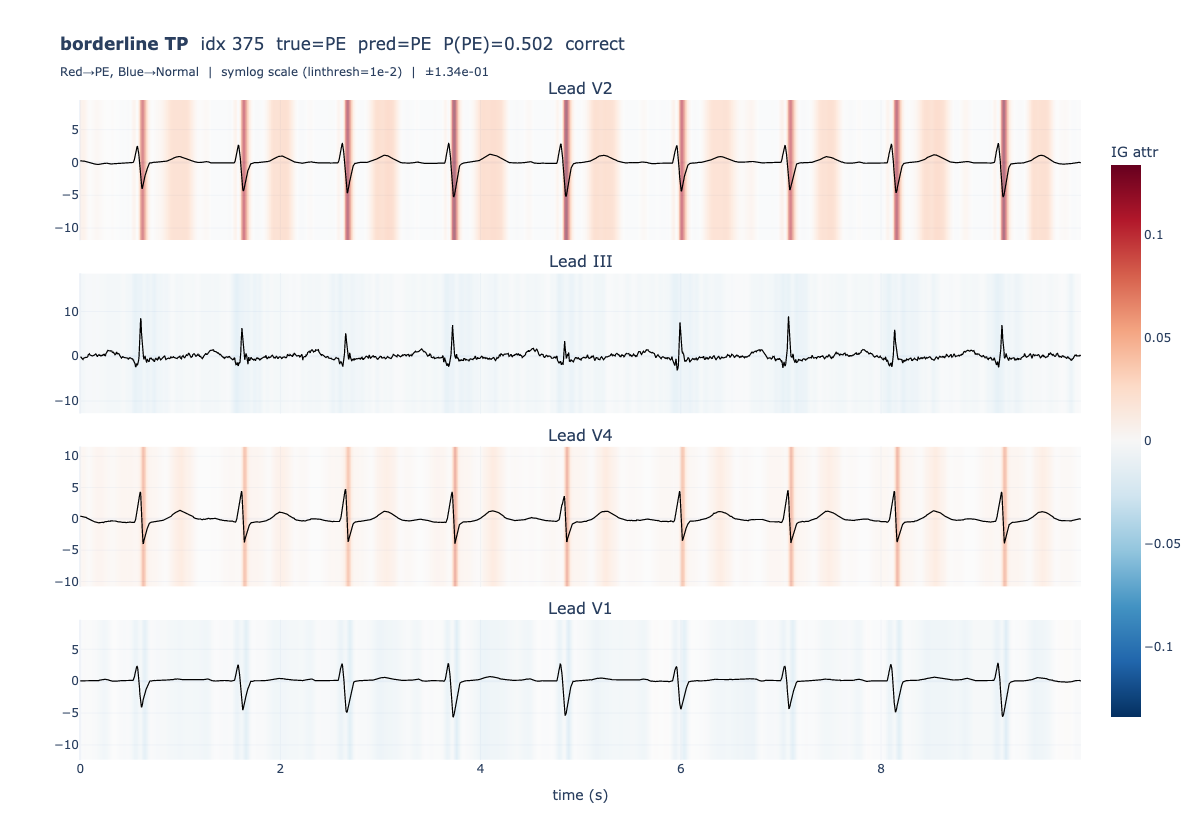

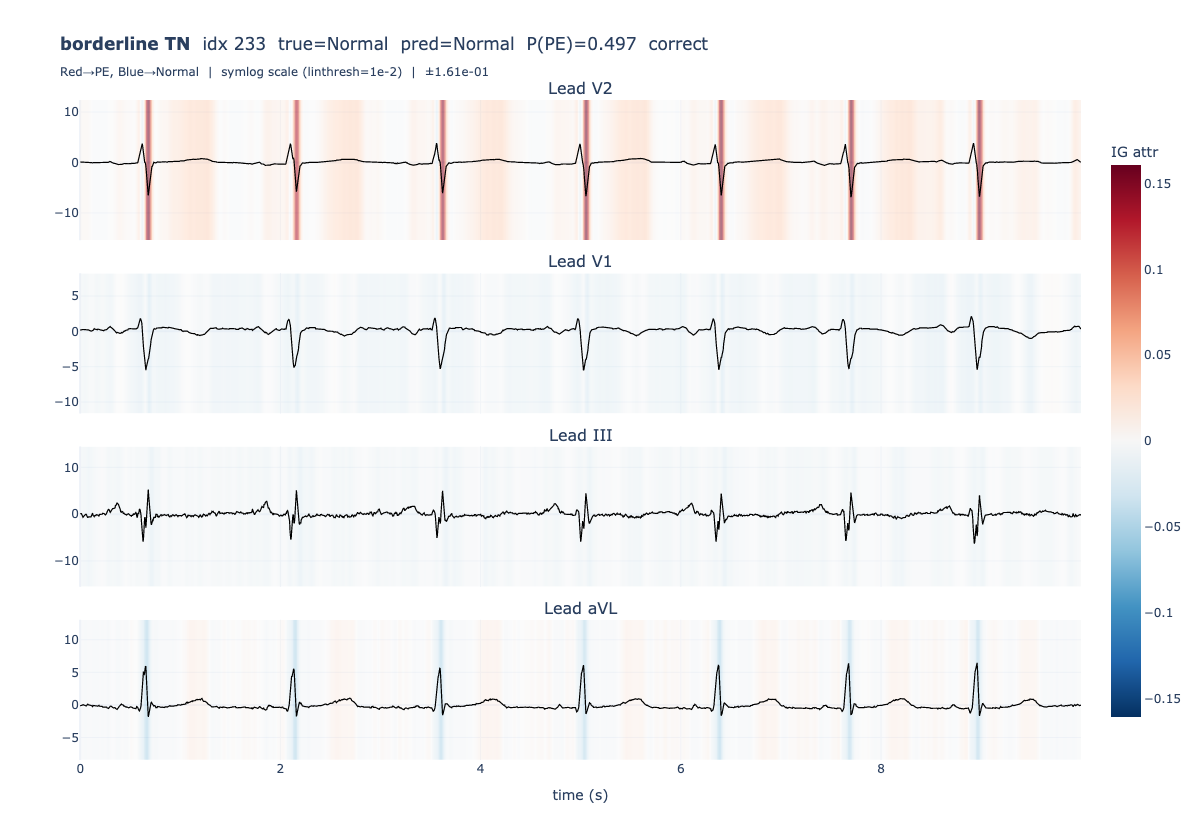

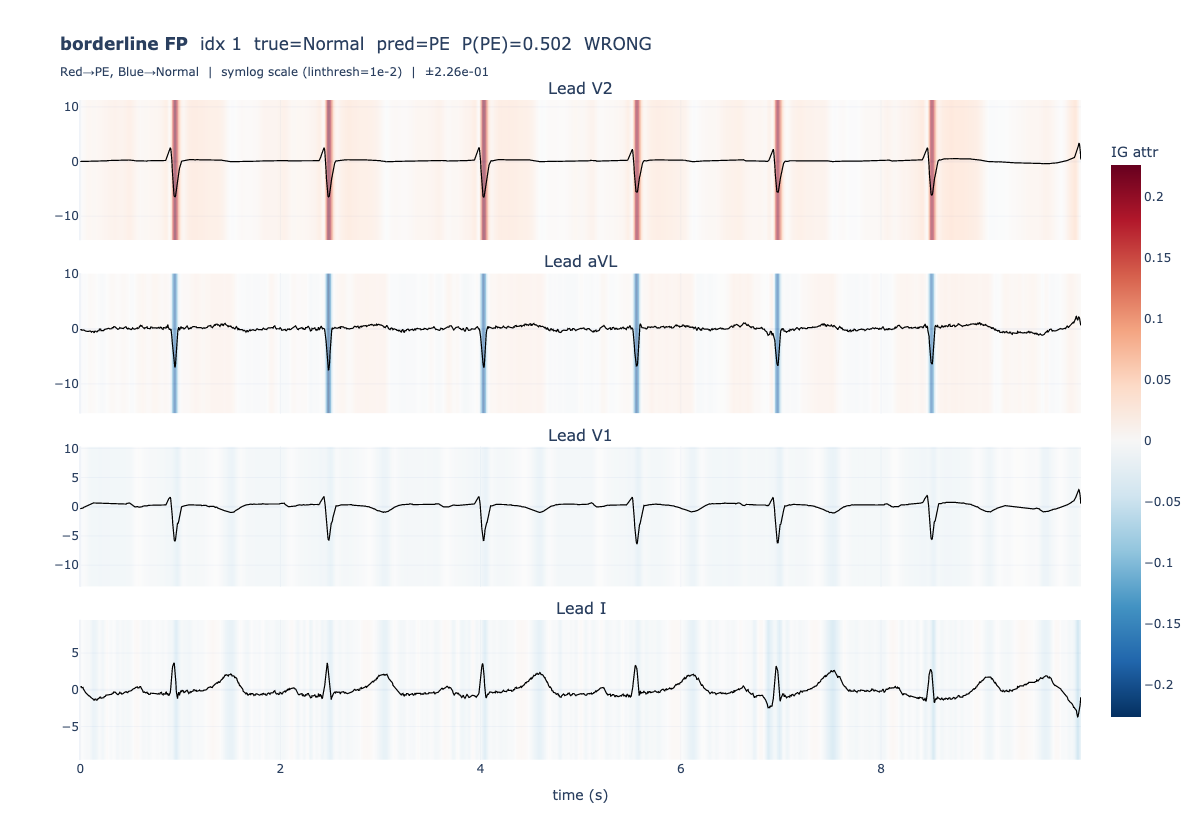

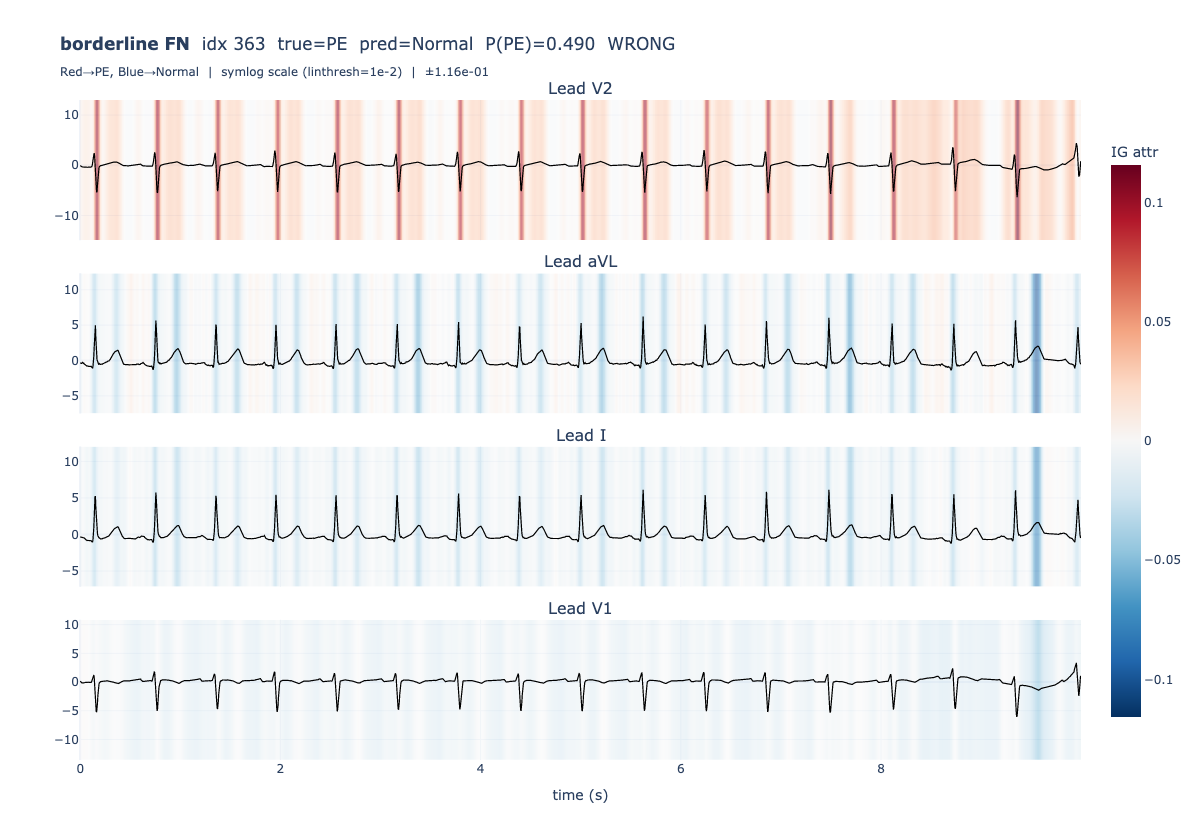

In [46]:
def plot_ig(label, idx, top_k=4, fs=250.0):
    attr = attributions[idx]
    ecg  = X_test[idx]
    t    = np.arange(ecg.shape[1]) / fs
    top_leads = list(np.argsort(-np.abs(attr).sum(axis=1))[:top_k])
    cmax = float(np.abs(attr[top_leads]).max()) or 1.0
    fig  = make_subplots(rows=top_k, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                         subplot_titles=[f'Lead {LEADS[L]}' for L in top_leads])
    for r, L in enumerate(top_leads, start=1):
        ymin, ymax = float(ecg[L].min()), float(ecg[L].max())
        ypad = (ymax-ymin)*0.15
        fig.add_trace(go.Heatmap(x=t, y=[ymin-ypad, ymax+ypad], z=[attr[L], attr[L]],
            colorscale='RdBu_r', zmid=0, zmin=-cmax, zmax=cmax, opacity=0.55,
            showscale=(r==1),
            colorbar=dict(title='IG attr', x=1.02, len=0.9) if r==1 else None), row=r, col=1)
        fig.add_trace(go.Scatter(x=t, y=ecg[L], mode='lines',
            line=dict(color='black', width=1.2), showlegend=False), row=r, col=1)
    pred = int(probs_test[idx] >= 0.5)
    fig.update_layout(template='plotly_white', width=1200, height=180*top_k+120,
        title=(f'<b>{label.replace("_"," ")}</b>  idx {idx}  '
               f'true={"PE" if y_test[idx]==1 else "Normal"}  '
               f'pred={"PE" if pred else "Normal"}  P(PE)={probs_test[idx]:.3f}  '
               f'{"correct" if pred==int(y_test[idx]) else "WRONG"}<br>'
               f'<sub>Red→PE, Blue→Normal  |  symlog scale (linthresh=1e-2)  |  ±{cmax:.2e}</sub>'))
    fig.update_xaxes(title_text='time (s)', row=top_k, col=1)
    return fig

for label, idx in ordered:
    plot_ig(label, idx).show()

## 8d. Grad-CAM

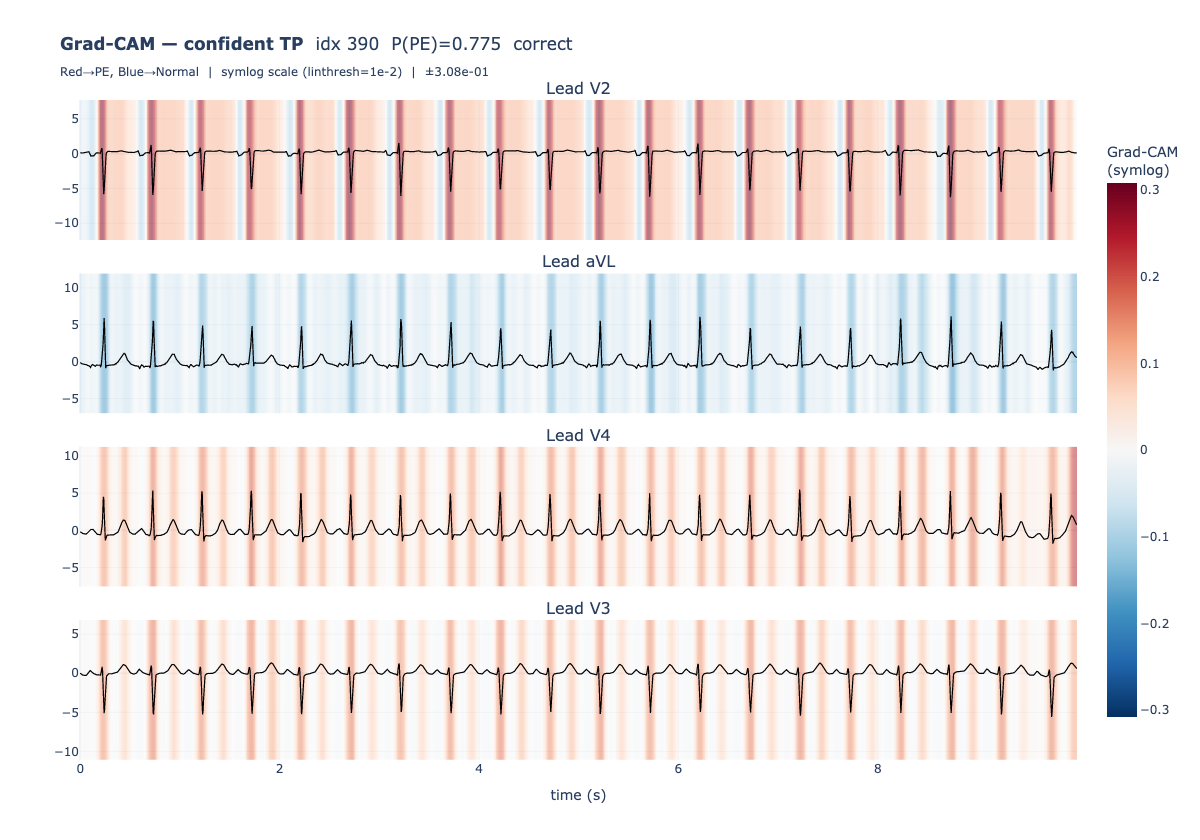

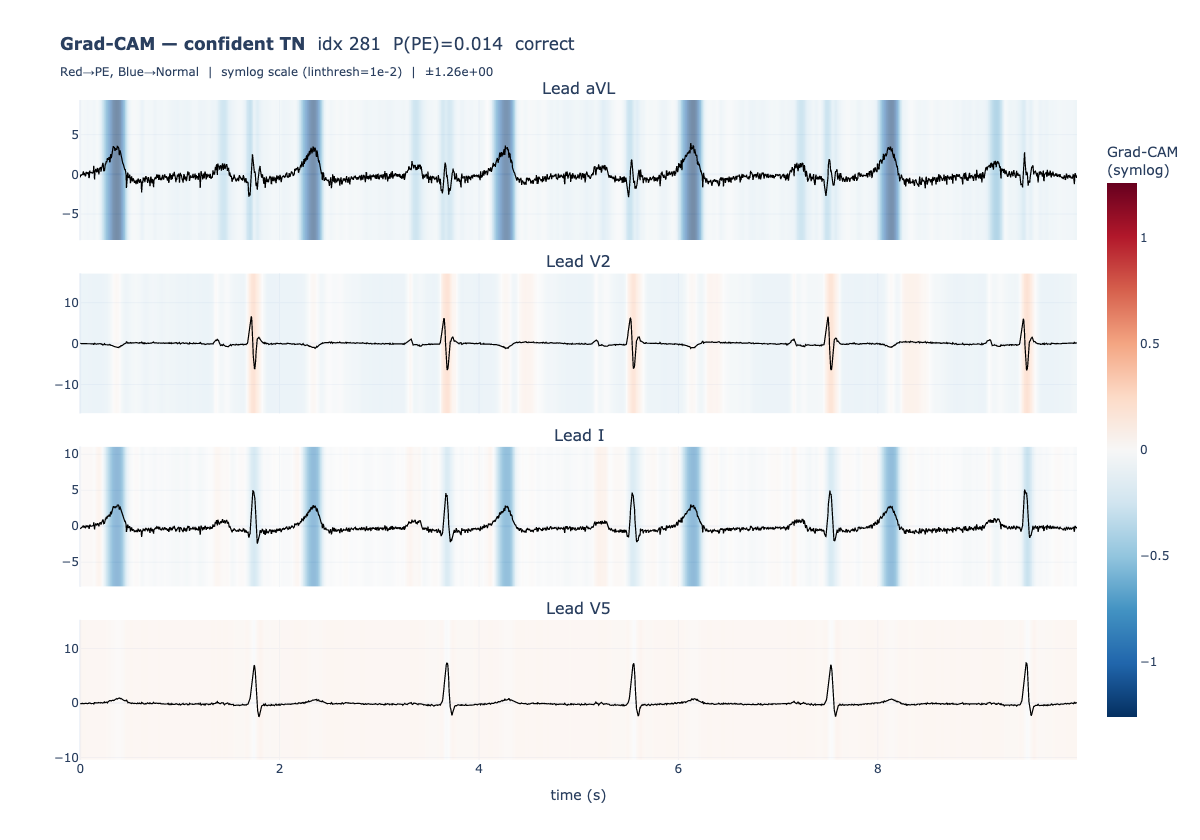

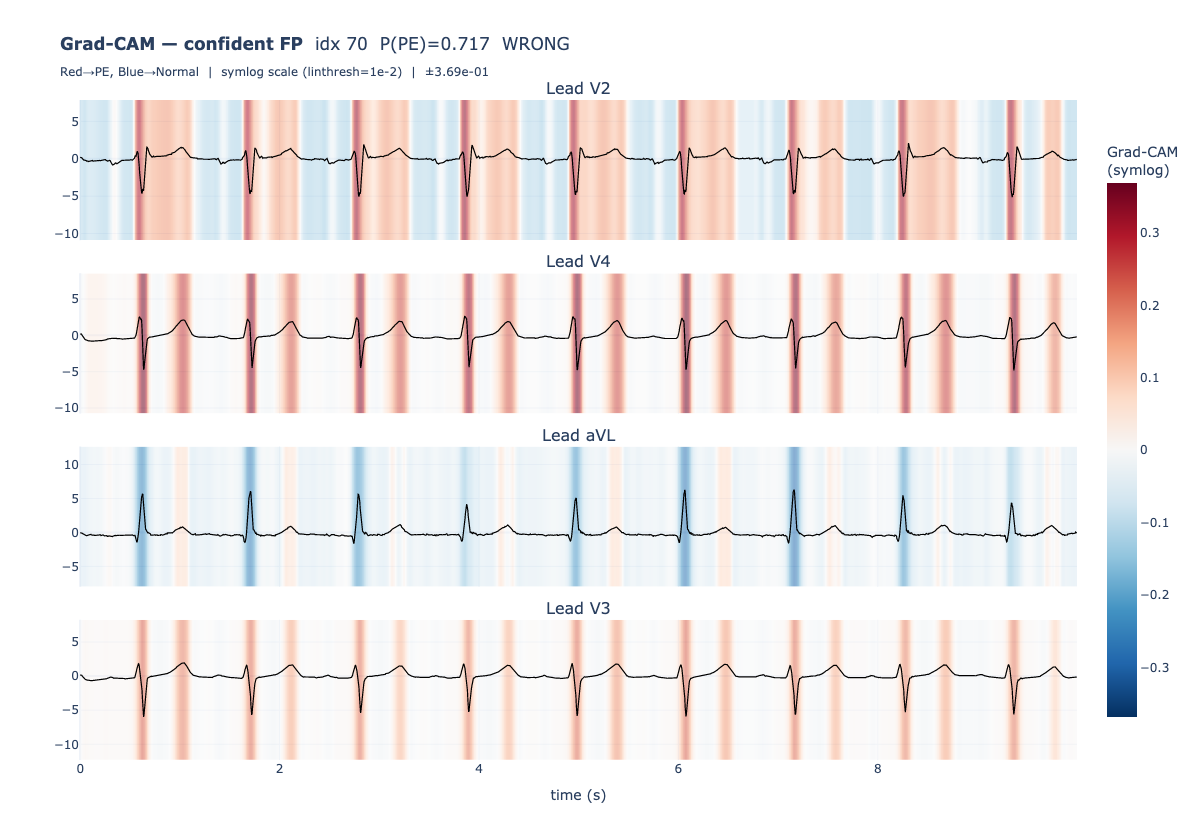

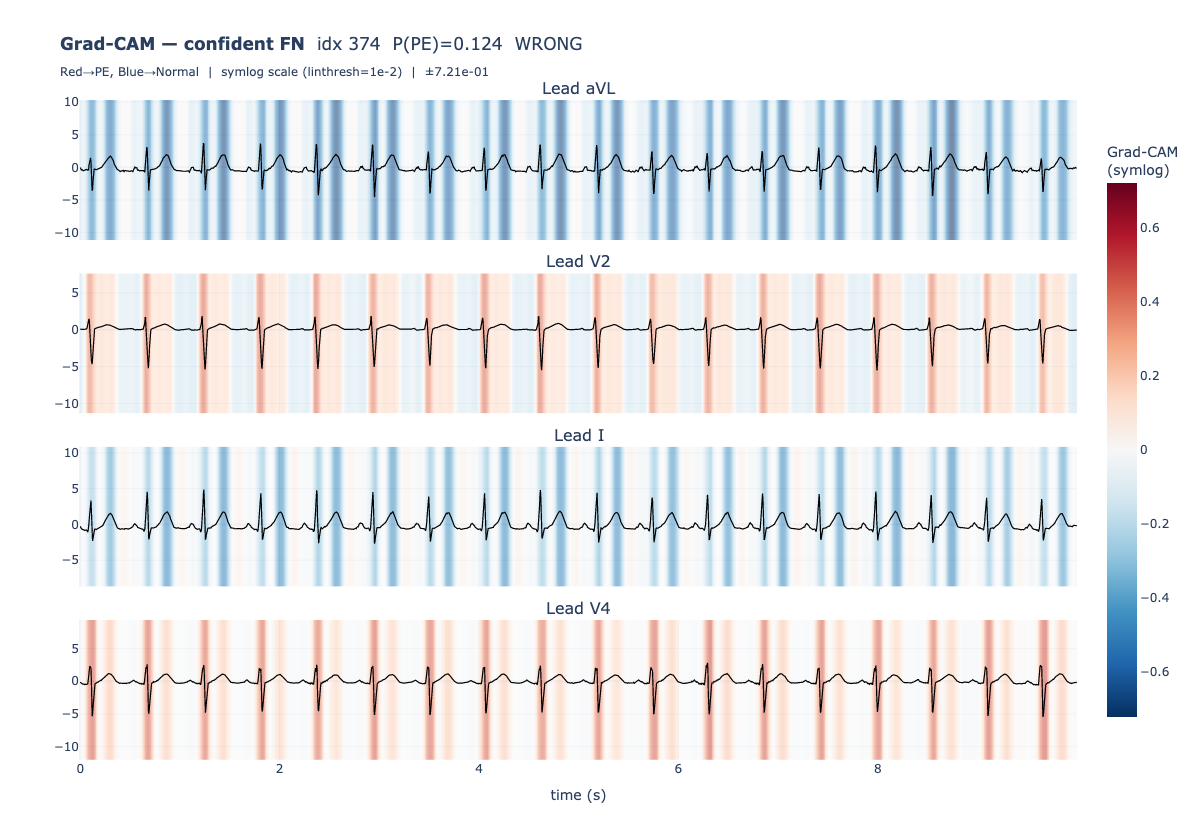

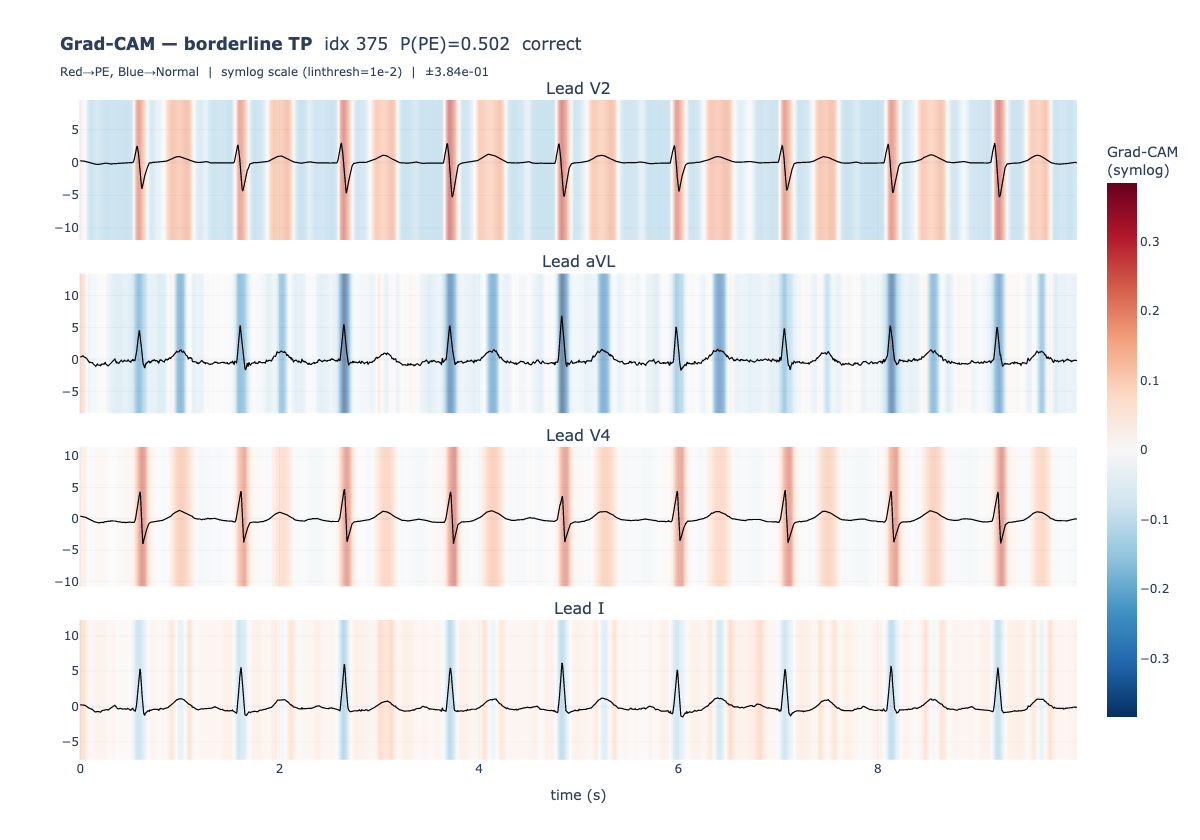

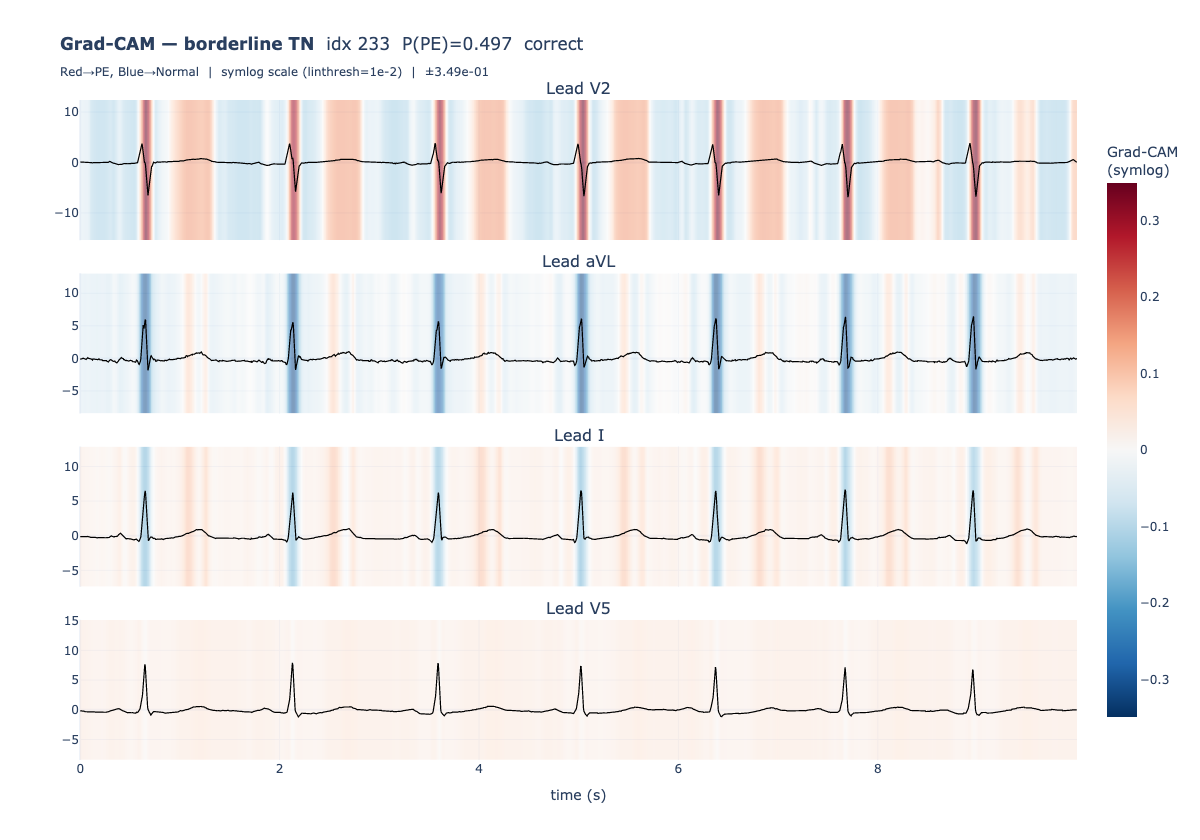

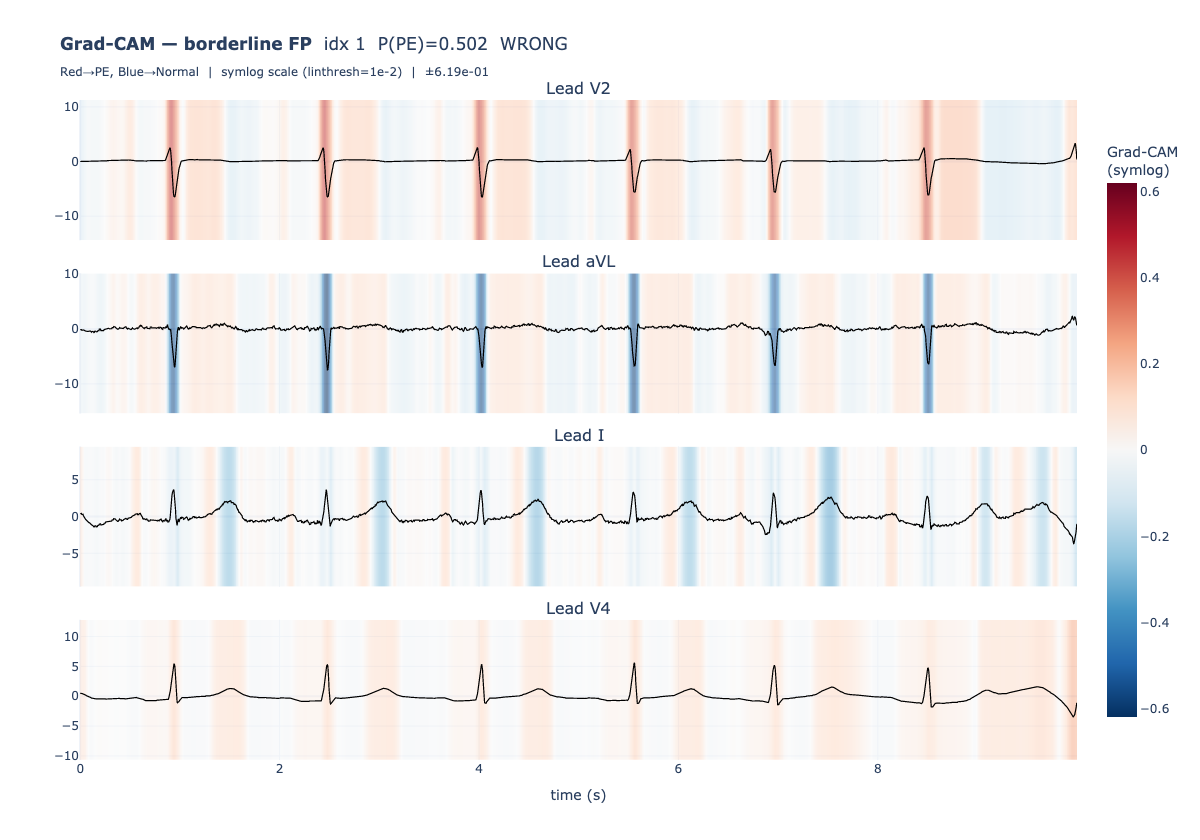

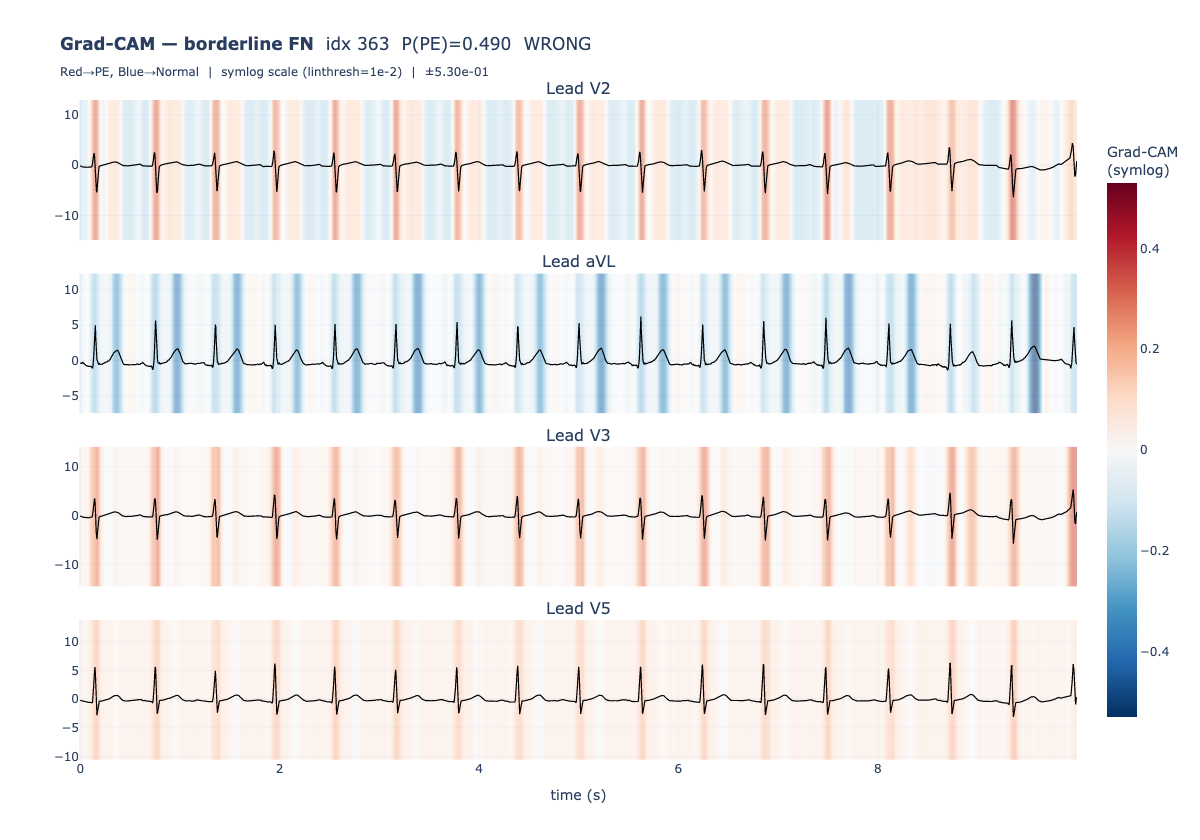

In [47]:
import torch.nn.functional as F

def symlog(x, linthresh=1e-2):
    """Symmetric log: sign(x) * log1p(|x| / linthresh). Compresses peaks, preserves sign."""
    return np.sign(x) * np.log1p(np.abs(x) / linthresh)

def gradcam(net, x_np, target_class=1, smooth_sigma=2.0):
    x = torch.tensor(x_np, dtype=torch.float32, device=device).unsqueeze(0)
    acts = {}
    def hook(_m, _i, o):
        acts['feat'] = o
        o.retain_grad()
    h = net.stages[-1]['conv'].register_forward_hook(hook)
    net.zero_grad()
    net(x)[0, target_class].backward()
    h.remove()
    feat = acts['feat']
    cam  = (feat.grad.mean(dim=(0,3)).unsqueeze(-1) * feat[0]).sum(dim=1)
    cam_up = F.interpolate(cam.unsqueeze(0).unsqueeze(0), size=(12, x_np.shape[1]),
                           mode='bilinear', align_corners=False).squeeze().detach().cpu().numpy()
    if smooth_sigma > 0:
        cam_up = gaussian_filter1d(cam_up, sigma=smooth_sigma, axis=1)
    return symlog(cam_up)   # log-compress before returning

gradcams = {idx: gradcam(net, X_test[idx]) for idx in cases.values()}

def plot_gradcam(label, idx, top_k=4, fs=250.0):
    cam  = gradcams[idx]   # already symlog-transformed
    ecg  = X_test[idx]
    t    = np.arange(ecg.shape[1]) / fs
    top_leads = list(np.argsort(-np.abs(cam).sum(axis=1))[:top_k])
    cmax = float(np.abs(cam[top_leads]).max()) or 1.0
    fig  = make_subplots(rows=top_k, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                         subplot_titles=[f'Lead {LEADS[L]}' for L in top_leads])
    for r, L in enumerate(top_leads, start=1):
        ymin, ymax = float(ecg[L].min()), float(ecg[L].max())
        ypad = (ymax-ymin)*0.15
        fig.add_trace(go.Heatmap(x=t, y=[ymin-ypad, ymax+ypad], z=[cam[L], cam[L]],
            colorscale='RdBu_r', zmid=0, zmin=-cmax, zmax=cmax, opacity=0.55,
            showscale=(r==1),
            colorbar=dict(title='Grad-CAM<br>(symlog)', x=1.02, len=0.9) if r==1 else None), row=r, col=1)
        fig.add_trace(go.Scatter(x=t, y=ecg[L], mode='lines',
            line=dict(color='black', width=1.2), showlegend=False), row=r, col=1)
    pred = int(probs_test[idx] >= 0.5)
    fig.update_layout(template='plotly_white', width=1200, height=180*top_k+120,
        title=(f'<b>Grad-CAM — {label.replace("_"," ")}</b>  idx {idx}  '
               f'P(PE)={probs_test[idx]:.3f}  '
               f'{"correct" if pred==int(y_test[idx]) else "WRONG"}<br>'
               f'<sub>Red→PE, Blue→Normal  |  symlog scale (linthresh=1e-2)  |  ±{cmax:.2e}</sub>'))
    fig.update_xaxes(title_text='time (s)', row=top_k, col=1)
    return fig

for label, idx in ordered:
    plot_gradcam(label, idx).show()

## 8e. Layer-by-layer activation flow (confident TP)

Picks the most-confident true positive and traces its representation through every layer of the network — input ECG → 3 stages of (conv → attention) → fusion → GAP → classifier.

**What you should see:**
- **Stage 1 conv (48 ch):** filter responses to local QRS/T-wave shapes (RF=52 ms after the block).
- **Stage 1 attn:** same shape, element-wise gated by the cross-lead attention's sigmoid output.
- **Stages 2 and 3:** progressively coarser temporal resolution (1250 → 625 → 312 samples) and more abstract feature channels (96 → 192).
- **Fusion (192 ch post-concat):** lead identity is gone, only abstract features remain.
- **GAP (192-d vector):** single vector summarising the entire 10-second ECG.
- **Linear (2 logits):** final class scores; softmax → P(PE).

In [48]:
TRACK_LEAD = 1   # 0=I, 1=II, ...
TRACK_IDX  = cases['confident_TP']
print(f'Tracking idx={TRACK_IDX}, lead={LEADS[TRACK_LEAD]}, P(PE)={probs_test[TRACK_IDX]:.3f}')

flow_acts = {}
def cap(name):
    def hook(_m, _i, output):
        if isinstance(output, tuple):
            output = output[0]
        flow_acts[name] = output.detach().cpu()
    return hook

handles = [
    net.stages[0]['conv'].register_forward_hook(cap('s1_conv')),
    net.stages[0]['attn'].register_forward_hook(cap('s1_attn')),
    net.stages[1]['conv'].register_forward_hook(cap('s2_conv')),
    net.stages[1]['attn'].register_forward_hook(cap('s2_attn')),
    net.stages[2]['conv'].register_forward_hook(cap('s3_conv')),
    net.stages[2]['attn'].register_forward_hook(cap('s3_attn')),
    net.fuse.register_forward_hook(cap('fuse')),
    net.gap.register_forward_hook(cap('gap')),
    net.fc.register_forward_hook(cap('fc')),
]

with torch.no_grad():
    x_in = torch.tensor(X_test[TRACK_IDX:TRACK_IDX+1], dtype=torch.float32, device=device)
    logits_tr = net(x_in)
    probs_tr  = torch.softmax(logits_tr, dim=1)

for h in handles:
    h.remove()

print(f'Logits  = {logits_tr.cpu().numpy().ravel()}')
print(f'Softmax = {probs_tr.cpu().numpy().ravel()}  ->  P(PE)={probs_tr[0,1].item():.4f}')
print('\nActivation shapes:')
for name, t in flow_acts.items():
    print(f'  {name:<10}  {tuple(t.shape)}')

Tracking idx=390, lead=II, P(PE)=0.775
Logits  = [-0.7194065   0.51992285]
Softmax = [0.22455274 0.7754472 ]  ->  P(PE)=0.7754

Activation shapes:
  s1_conv     (1, 12, 48, 1250)
  s1_attn     (1, 12, 48, 1250)
  s2_conv     (1, 12, 96, 625)
  s2_attn     (1, 12, 96, 625)
  s3_conv     (1, 12, 192, 312)
  s3_attn     (1, 12, 192, 312)
  fuse        (1, 192, 312)
  gap         (1, 192, 1)
  fc          (1, 2)


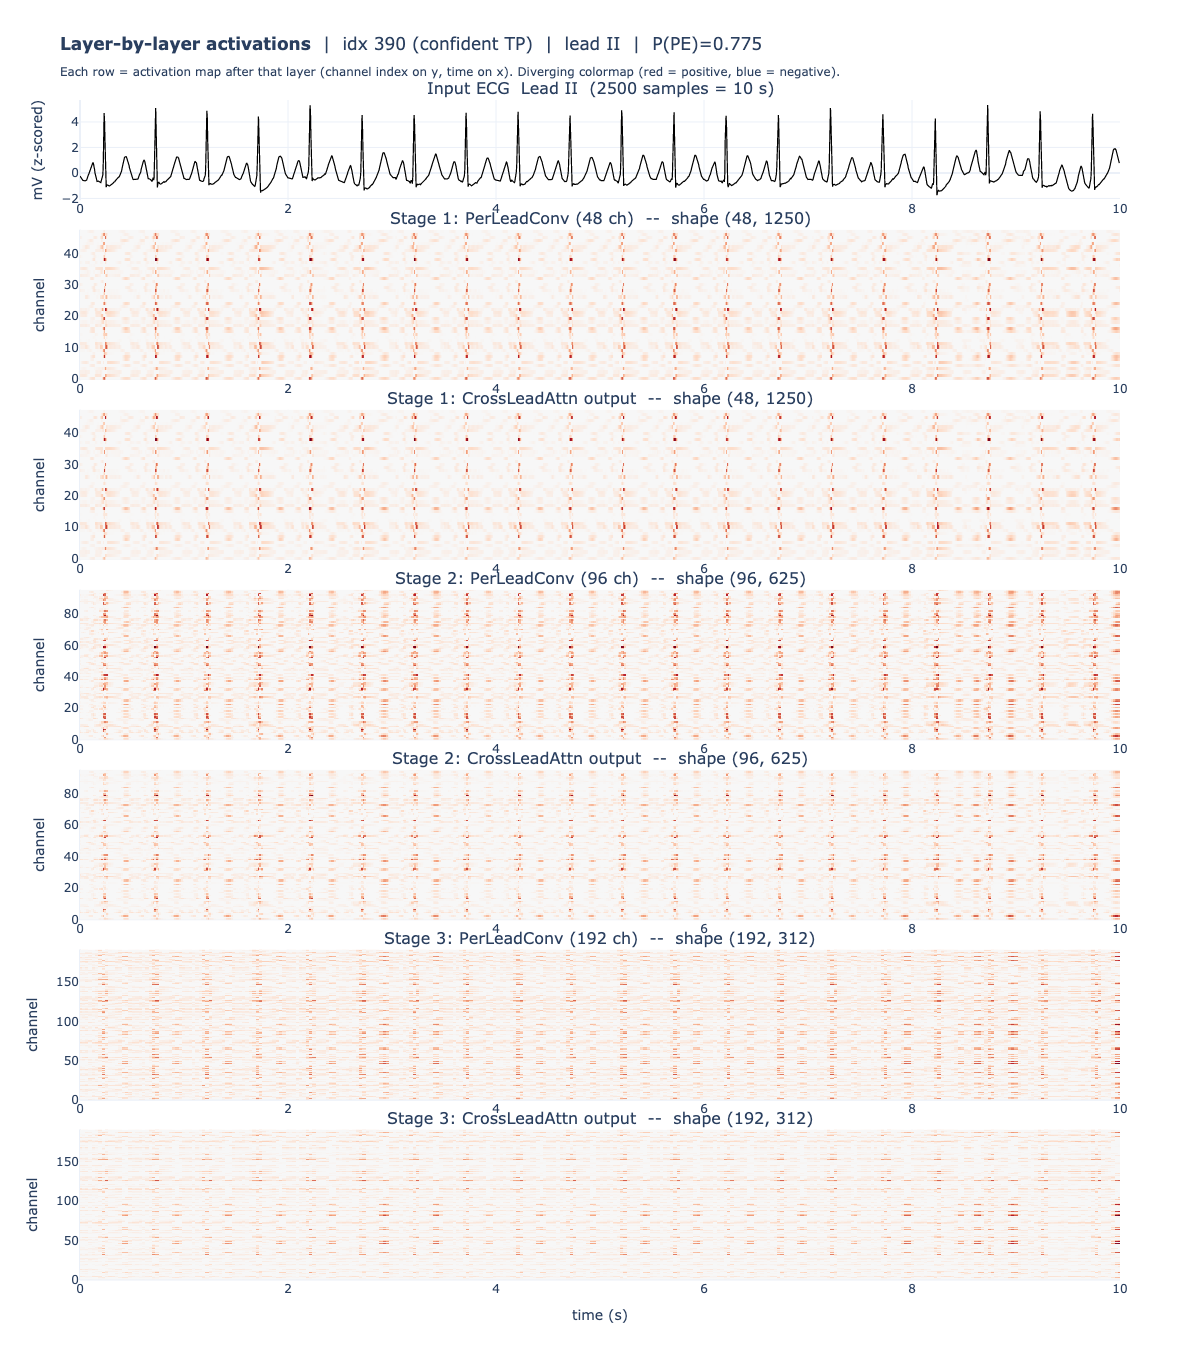

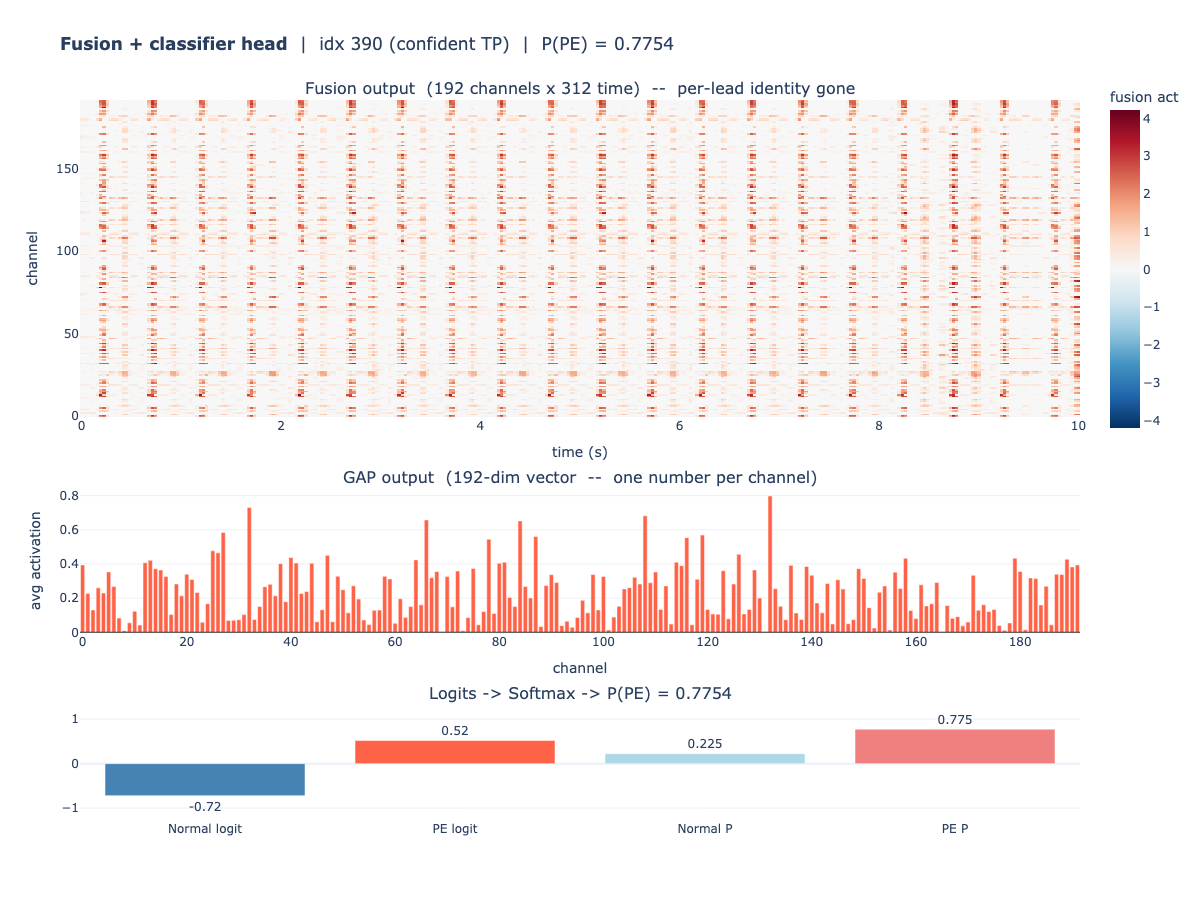

In [49]:
ecg_lead = X_test[TRACK_IDX, TRACK_LEAD, :]
t_input  = np.arange(2500) / 250.0

stage_keys = [
    ('Stage 1: PerLeadConv (48 ch)',   's1_conv'),
    ('Stage 1: CrossLeadAttn output',  's1_attn'),
    ('Stage 2: PerLeadConv (96 ch)',   's2_conv'),
    ('Stage 2: CrossLeadAttn output',  's2_attn'),
    ('Stage 3: PerLeadConv (192 ch)',  's3_conv'),
    ('Stage 3: CrossLeadAttn output',  's3_attn'),
]

n_rows = 1 + len(stage_keys)
fig_l = make_subplots(
    rows=n_rows, cols=1, shared_xaxes=False, vertical_spacing=0.025,
    row_heights=[0.10] + [0.15] * len(stage_keys),
    subplot_titles=[f'Input ECG  Lead {LEADS[TRACK_LEAD]}  (2500 samples = 10 s)'] +
                   [f'{name}  --  shape {tuple(flow_acts[k].shape[2:])}'
                    for name, k in stage_keys],
)
fig_l.add_trace(go.Scatter(x=t_input, y=ecg_lead, mode='lines',
                           line=dict(color='black', width=1.2), showlegend=False), row=1, col=1)

for r, (name, key) in enumerate(stage_keys, start=2):
    a = flow_acts[key][0, TRACK_LEAD].numpy()    # (C, T_stage)
    C, T_stage = a.shape
    t_stage = np.linspace(0, 10.0, T_stage)
    cmax = float(np.abs(a).max()) or 1.0
    fig_l.add_trace(go.Heatmap(
        x=t_stage, y=np.arange(C), z=a,
        colorscale='RdBu_r', zmid=0, zmin=-cmax, zmax=cmax,
        showscale=False,
        hovertemplate='ch=%{y}<br>t=%{x:.2f}s<br>act=%{z:.3f}<extra></extra>',
    ), row=r, col=1)

fig_l.update_xaxes(range=[0, 10.0])
fig_l.update_yaxes(title_text='mV (z-scored)', row=1, col=1)
for r in range(2, n_rows + 1):
    fig_l.update_yaxes(title_text='channel', row=r, col=1)
fig_l.update_xaxes(title_text='time (s)', row=n_rows, col=1)
fig_l.update_layout(
    template='plotly_white', width=1200, height=180 * n_rows + 100,
    title=(f'<b>Layer-by-layer activations</b>  |  idx {TRACK_IDX} (confident TP)  |  '
           f'lead {LEADS[TRACK_LEAD]}  |  P(PE)={probs_test[TRACK_IDX]:.3f}<br>'
           f'<sub>Each row = activation map after that layer (channel index on y, time on x). '
           f'Diverging colormap (red = positive, blue = negative).</sub>'),
)
fig_l.show()


# Fusion + classifier-head outputs (no per-lead axis anymore)
fuse_out = flow_acts['fuse'][0].numpy()           # (192, T_stage)
gap_out  = flow_acts['gap'][0, :, 0].numpy()      # (192,)
fc_out   = flow_acts['fc'][0].numpy()             # (2,)
sm_out   = probs_tr[0].cpu().numpy()              # (2,)
C_fuse, T_fuse = fuse_out.shape

fig_h = make_subplots(
    rows=3, cols=1, row_heights=[0.55, 0.25, 0.20], vertical_spacing=0.10,
    subplot_titles=(
        f'Fusion output  ({C_fuse} channels x {T_fuse} time)  --  per-lead identity gone',
        f'GAP output  ({len(gap_out)}-dim vector  --  one number per channel)',
        f'Logits -> Softmax -> P(PE) = {sm_out[1]:.4f}',
    ),
)
cmax_f = float(np.abs(fuse_out).max()) or 1.0
fig_h.add_trace(go.Heatmap(x=np.linspace(0, 10, T_fuse), y=np.arange(C_fuse), z=fuse_out,
    colorscale='RdBu_r', zmid=0, zmin=-cmax_f, zmax=cmax_f, showscale=True,
    colorbar=dict(title='fusion act', x=1.02, len=0.5, y=0.78)), row=1, col=1)
fig_h.add_trace(go.Bar(x=np.arange(len(gap_out)), y=gap_out,
    marker_color=['tomato' if v > 0 else 'steelblue' for v in gap_out],
    showlegend=False), row=2, col=1)
fig_h.add_hline(y=0, line=dict(color='black', width=1), row=2, col=1)
fig_h.add_trace(go.Bar(
    x=['Normal logit', 'PE logit', 'Normal P', 'PE P'],
    y=[fc_out[0], fc_out[1], sm_out[0], sm_out[1]],
    marker_color=['steelblue', 'tomato', 'lightblue', 'lightcoral'],
    text=[f'{fc_out[0]:.2f}', f'{fc_out[1]:.2f}', f'{sm_out[0]:.3f}', f'{sm_out[1]:.3f}'],
    textposition='outside', showlegend=False,
), row=3, col=1)
fig_h.update_xaxes(title_text='time (s)', row=1, col=1)
fig_h.update_yaxes(title_text='channel', row=1, col=1)
fig_h.update_xaxes(title_text='channel', row=2, col=1)
fig_h.update_yaxes(title_text='avg activation', row=2, col=1)
fig_h.update_layout(template='plotly_white', width=1200, height=900,
    title=f'<b>Fusion + classifier head</b>  |  idx {TRACK_IDX} (confident TP)  |  '
          f'P(PE) = {probs_test[TRACK_IDX]:.4f}')
fig_h.show()

## 8f. GAP voting — per-channel contribution to PE decision

After GAP, the 192-dim vector is fed into a linear classifier: `logit[c] = Σ gap[i] * W[c, i] + b[c]`.

The **per-channel contribution to the PE-vs-Normal margin** is:

```
vote[i] = gap[i] * (W[PE, i] - W[Normal, i])
```

- `vote[i] > 0` → this channel's activation **pushes toward PE**
- `vote[i] < 0` → this channel's activation **pushes toward Normal**

The sum of all votes + bias difference = `logit[PE] - logit[Normal]` (the raw decision score before softmax).

Plots below show:
1. **Structural vote weights** `(W[PE,i] - W[Normal,i])`: which channels are wired to detect PE regardless of sample.
2. **Per-sample vote contributions** for the confident TP and confident TN.
3. **Population-level average vote** by class across the full test set.

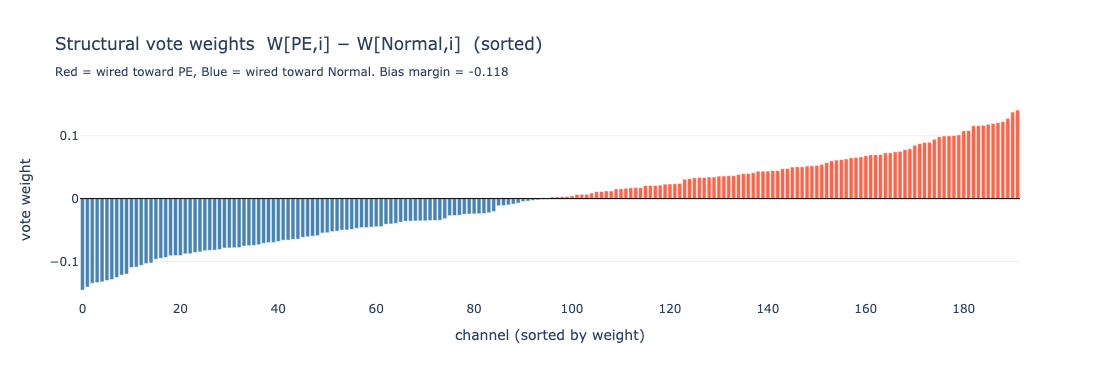

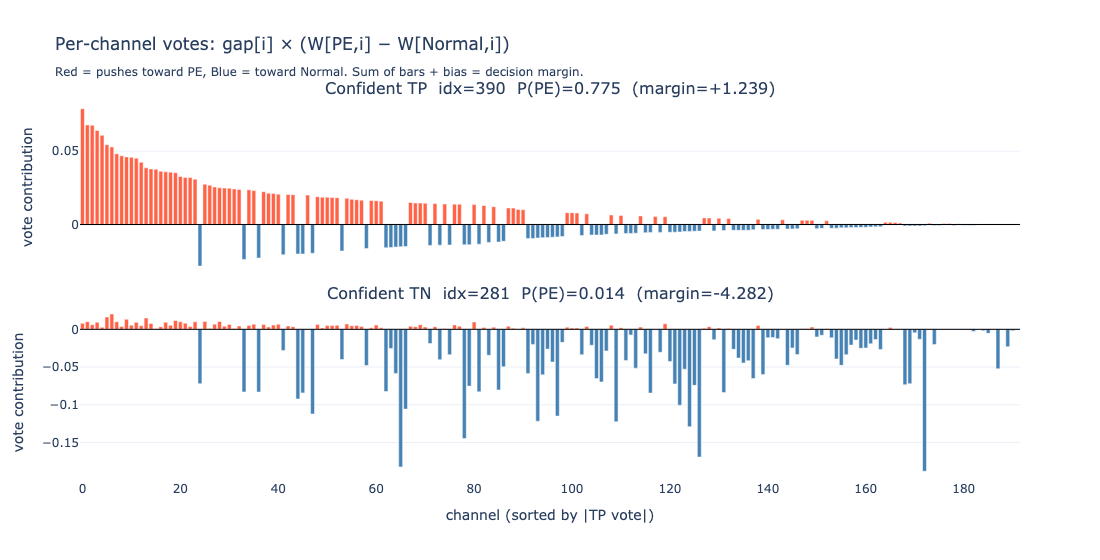

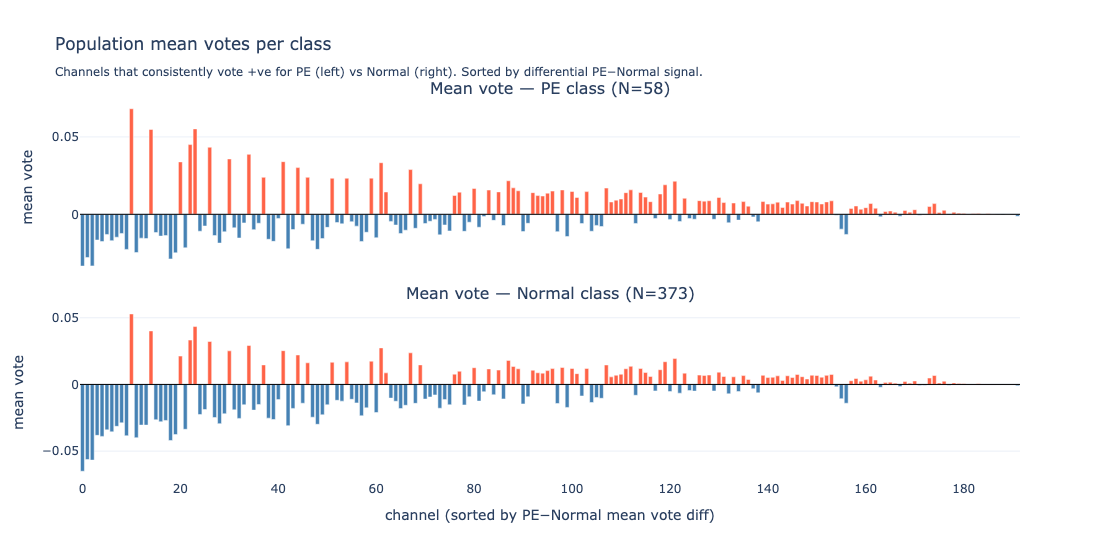

Bias margin b[PE]-b[Normal] = -0.1176
Mean total margin — PE    samples: +0.2282
Mean total margin — Normal samples: -0.7681


In [50]:
# ── 1. Structural vote weights (model weights, independent of any sample) ──────
W = net.fc.weight.detach().cpu().numpy()   # (2, 192)  W[0]=Normal, W[1]=PE
b = net.fc.bias.detach().cpu().numpy()     # (2,)
vote_weights = W[1] - W[0]                # (192,) — positive = PE-wired channel

sort_idx = np.argsort(vote_weights)
colors_w = ['tomato' if v > 0 else 'steelblue' for v in vote_weights[sort_idx]]

fig_w = go.Figure(go.Bar(
    x=np.arange(len(vote_weights)), y=vote_weights[sort_idx],
    marker_color=colors_w, showlegend=False,
    hovertemplate='orig ch=%{customdata}<br>vote weight=%{y:.3f}<extra></extra>',
    customdata=sort_idx,
))
fig_w.add_hline(y=0, line=dict(color='black', width=1))
fig_w.update_layout(
    template='plotly_white', width=1100, height=380,
    title='Structural vote weights  W[PE,i] − W[Normal,i]  (sorted)<br>'
          '<sub>Red = wired toward PE, Blue = wired toward Normal. '
          'Bias margin = {:.3f}</sub>'.format(float(b[1] - b[0])),
    xaxis_title='channel (sorted by weight)', yaxis_title='vote weight',
)
fig_w.show()

# ── 2. Per-sample votes for confident TP vs confident TN ───────────────────────
# We need GAP activations for both samples
def get_gap(net, x_np, device):
    store = {}
    h = net.gap.register_forward_hook(lambda _m, _i, o: store.update({'gap': o.detach().cpu()}))
    with torch.no_grad():
        net(torch.tensor(x_np[None], dtype=torch.float32, device=device))
    h.remove()
    return store['gap'][0, :, 0].numpy()   # (192,)

tp_idx = cases['confident_TP']
tn_idx = cases['confident_TN']
gap_tp = get_gap(net, X_test[tp_idx], device)
gap_tn = get_gap(net, X_test[tn_idx], device)

votes_tp = gap_tp * vote_weights   # (192,) contribution per channel
votes_tn = gap_tn * vote_weights

# Sort by |votes_tp| so most influential channels are visible
sort_abs = np.argsort(-np.abs(votes_tp))

fig_vs = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=(
        f'Confident TP  idx={tp_idx}  P(PE)={probs_test[tp_idx]:.3f}  '
        f'(margin={votes_tp.sum()+b[1]-b[0]:+.3f})',
        f'Confident TN  idx={tn_idx}  P(PE)={probs_test[tn_idx]:.3f}  '
        f'(margin={votes_tn.sum()+b[1]-b[0]:+.3f})',
    ))
for row, (votes, label) in enumerate([(votes_tp, 'TP'), (votes_tn, 'TN')], start=1):
    fig_vs.add_trace(go.Bar(
        x=np.arange(len(votes)), y=votes[sort_abs],
        marker_color=['tomato' if v > 0 else 'steelblue' for v in votes[sort_abs]],
        showlegend=False,
        hovertemplate='orig ch=%{customdata}<br>vote=%{y:.4f}<extra></extra>',
        customdata=sort_abs,
    ), row=row, col=1)
    fig_vs.add_hline(y=0, line=dict(color='black', width=1), row=row, col=1)
    fig_vs.update_yaxes(title_text='vote contribution', row=row, col=1)
fig_vs.update_xaxes(title_text='channel (sorted by |TP vote|)', row=2, col=1)
fig_vs.update_layout(template='plotly_white', width=1100, height=560,
    title='Per-channel votes: gap[i] × (W[PE,i] − W[Normal,i])<br>'
          '<sub>Red = pushes toward PE, Blue = toward Normal. '
          'Sum of bars + bias = decision margin.</sub>')
fig_vs.show()

# ── 3. Population-level mean votes by class ────────────────────────────────────
# Run GAP hooks over all test samples
gap_storage = []
h = net.gap.register_forward_hook(
    lambda _m, _i, o: gap_storage.append(o.detach().cpu().squeeze(-1)))
with torch.no_grad():
    for (xb,) in DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32)), batch_size=64):
        net(xb.to(device))
h.remove()
all_gaps = torch.cat(gap_storage, dim=0).numpy()   # (N_test, 192)

# Per-sample votes: (N_test, 192)
all_votes = all_gaps * vote_weights[None, :]

mean_votes_pe   = all_votes[y_test == 1].mean(axis=0)
mean_votes_norm = all_votes[y_test == 0].mean(axis=0)

# Sort by (PE mean - Normal mean) to highlight differential channels
diff_order = np.argsort(-(mean_votes_pe - mean_votes_norm))

fig_pop = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=(
        f'Mean vote — PE class (N={int(y_test.sum())})',
        f'Mean vote — Normal class (N={int((y_test==0).sum())})',
    ))
for row, (mv, label) in enumerate([(mean_votes_pe, 'PE'), (mean_votes_norm, 'Normal')], start=1):
    fig_pop.add_trace(go.Bar(
        x=np.arange(len(mv)), y=mv[diff_order],
        marker_color=['tomato' if v > 0 else 'steelblue' for v in mv[diff_order]],
        showlegend=False,
        hovertemplate='orig ch=%{customdata}<br>mean vote=%{y:.4f}<extra></extra>',
        customdata=diff_order,
    ), row=row, col=1)
    fig_pop.add_hline(y=0, line=dict(color='black', width=1), row=row, col=1)
    fig_pop.update_yaxes(title_text='mean vote', row=row, col=1)
fig_pop.update_xaxes(title_text='channel (sorted by PE−Normal mean vote diff)', row=2, col=1)
fig_pop.update_layout(template='plotly_white', width=1100, height=560,
    title='Population mean votes per class<br>'
          '<sub>Channels that consistently vote +ve for PE (left) vs Normal (right). '
          'Sorted by differential PE−Normal signal.</sub>')
fig_pop.show()

print(f'Bias margin b[PE]-b[Normal] = {b[1]-b[0]:+.4f}')
print(f'Mean total margin — PE    samples: {(all_votes[y_test==1].sum(axis=1) + b[1]-b[0]).mean():+.4f}')
print(f'Mean total margin — Normal samples: {(all_votes[y_test==0].sum(axis=1) + b[1]-b[0]).mean():+.4f}')
